# 05 - xAI Analysis: vollstaendige SHAP-Suite (basiert auf NB03)

Konsumiert angereicherte `shap_{model}_{plant}.pkl` (NB03): `shap_values`, `X`, `feature_names`, `base_value`, `timestamps`.

**Plots:** Bar | Beeswarm | Dependence | Waterfall | Force | Modellvergleich (MAE/RMSE/Pinball) | Pinball-Linien | SHAP-Heatmap (Stunde x Monat) | Forecast vs Actual + Baender.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys, pickle, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap

from plot_utils import MODEL_COLORS, apply_style, get_model_color
apply_style()

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SHAP_DIR    = PROJECT_ROOT / "results" / "shap_explanations"
FORECAST_DIR= PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR  = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
for d in [TABLES_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PLANTS = ["Schonungen", "Schwanfeld", "Trabelsdorf", "Obbach"]
MODELS = {"xgb": "XGBoost", "qgb": "QGB", "qrf": "QRF", "qr": "QR"}
PLOT_PLANT = "Schonungen"   # Referenz-Standort fuer lokale Plots
print("Setup OK")

Setup OK


## 1. SHAP-pkls laden (angereichert: shap, X, base, timestamps)

In [2]:
shap_data = {}
for plant in PLANTS:
    for mdl in MODELS:
        fp = SHAP_DIR / f"shap_{mdl}_{plant.lower()}.pkl"
        if fp.exists():
            with open(fp, "rb") as f:
                shap_data[(plant, mdl)] = pickle.load(f)
FEATURES = shap_data[(PLANTS[0], "xgb")]["feature_names"]
sample = shap_data[(PLANTS[0], "xgb")]
print(f"Loaded {len(shap_data)} files | {len(FEATURES)} features")
print("Keys per file:", list(sample.keys()))
print("Shapes:", "shap", sample["shap_values"].shape, "| X", np.asarray(sample["X"]).shape,
      "| base", round(float(sample["base_value"]), 3))

Loaded 12 files | 26 features
Keys per file: ['shap_values', 'X', 'feature_names', 'base_value', 'timestamps']
Shapes: shap (5000, 26) | X (5000, 26) | base 0.342


## 2. Bar Plot: globale Feature-Importance (mean|SHAP|) je Modell

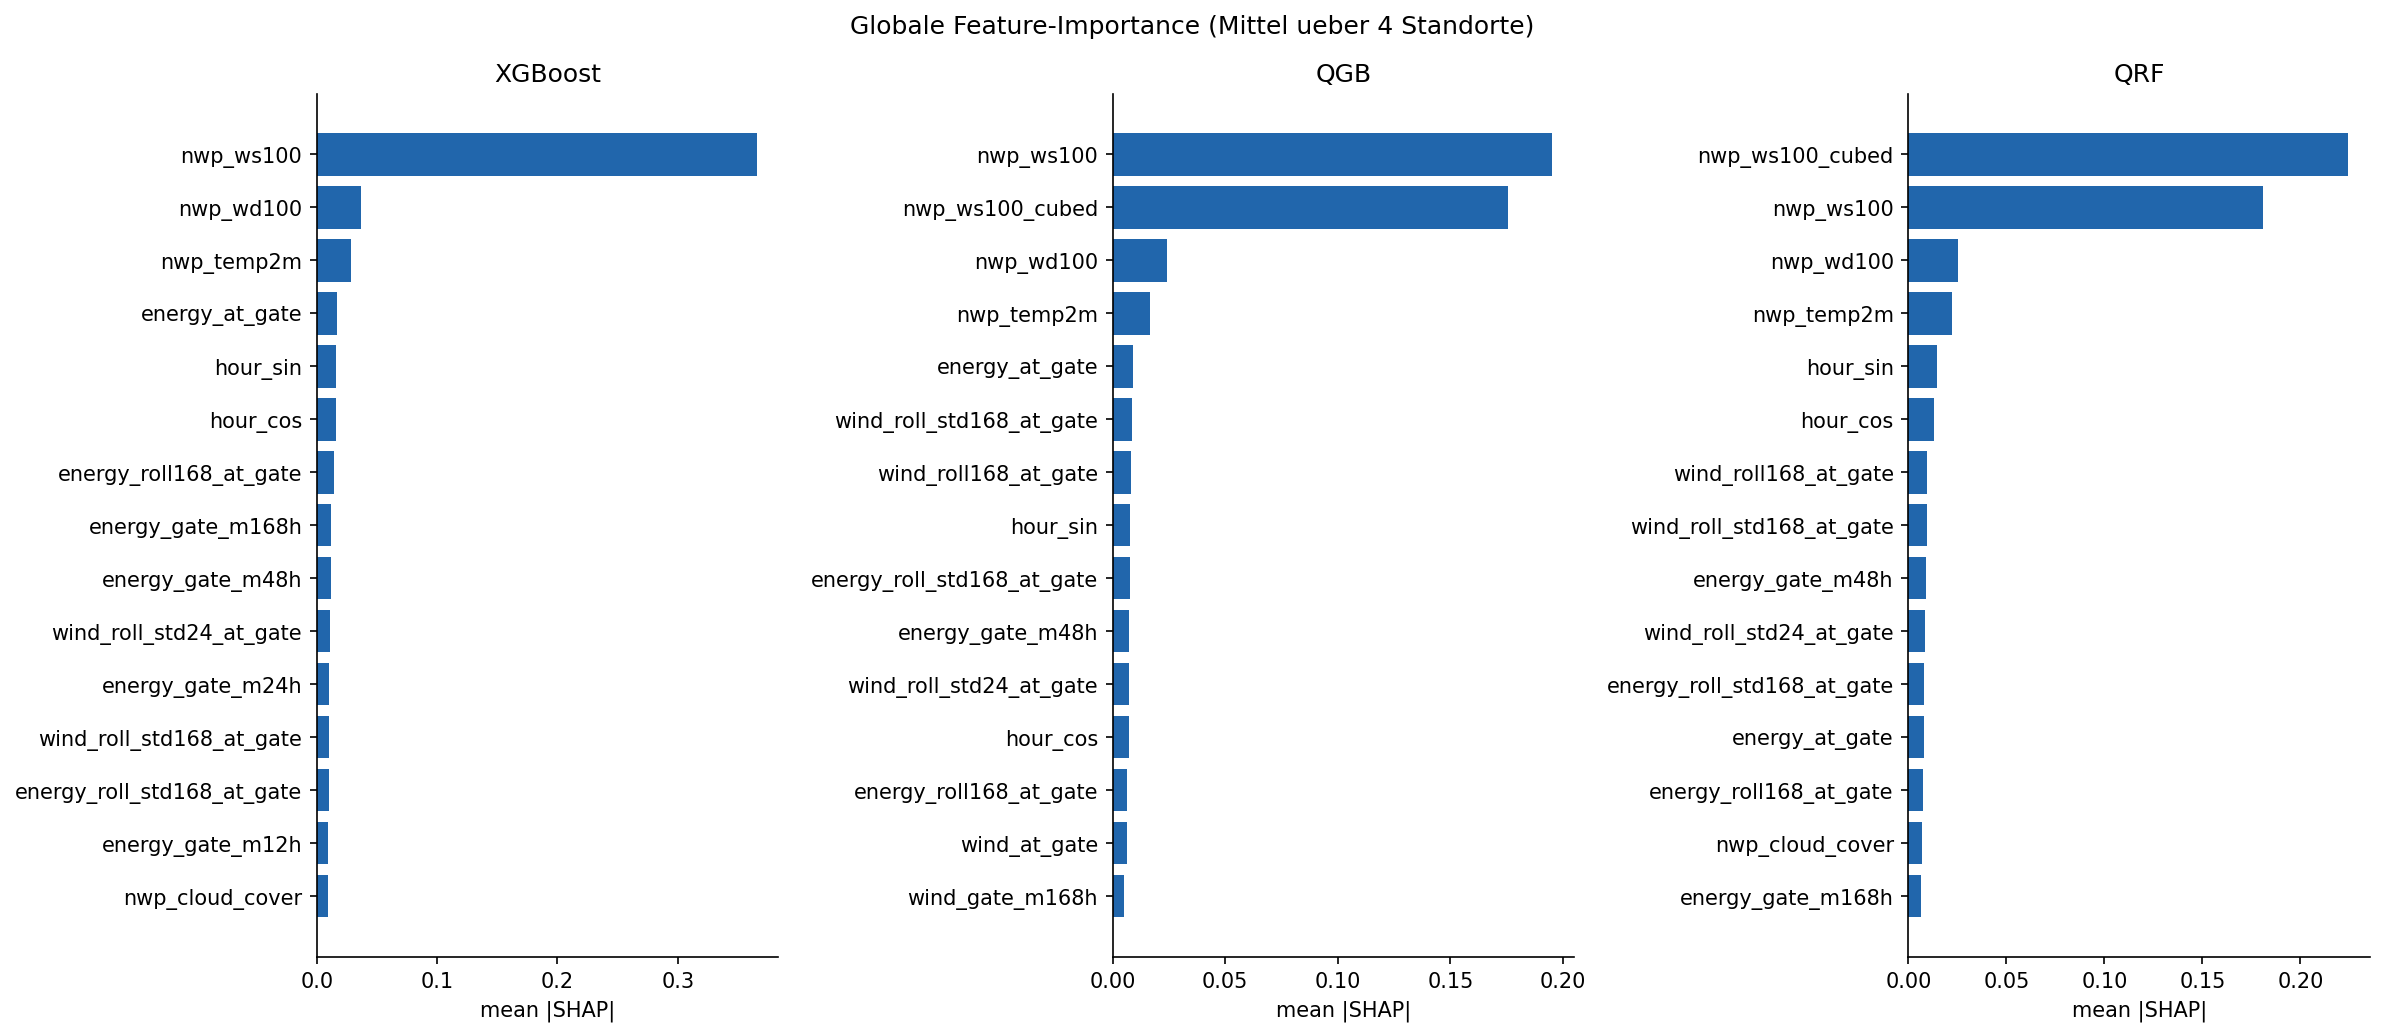

In [3]:
rows = []
for (plant, mdl), d in shap_data.items():
    imp = np.abs(d["shap_values"]).mean(axis=0)
    for f, v in zip(FEATURES, imp):
        rows.append({"plant": plant, "model": MODELS[mdl], "feature": f, "importance": float(v)})
imp_df = pd.DataFrame(rows)
imp_df.to_csv(TABLES_DIR / "shap_feature_importance.csv", index=False)
glob = imp_df.groupby(["model", "feature"])["importance"].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, m in zip(axes, ["XGBoost", "QGB", "QRF"]):
    top = glob[glob["model"] == m].nlargest(15, "importance").sort_values("importance")
    ax.barh(top["feature"], top["importance"], color="#2166ac")
    ax.set_title(m); ax.set_xlabel("mean |SHAP|")
plt.suptitle("Globale Feature-Importance (Mittel ueber 4 Standorte)"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_bar_importance.png", dpi=150); plt.show()

## 3. Beeswarm / Summary Plot (je Modell, Schonungen)

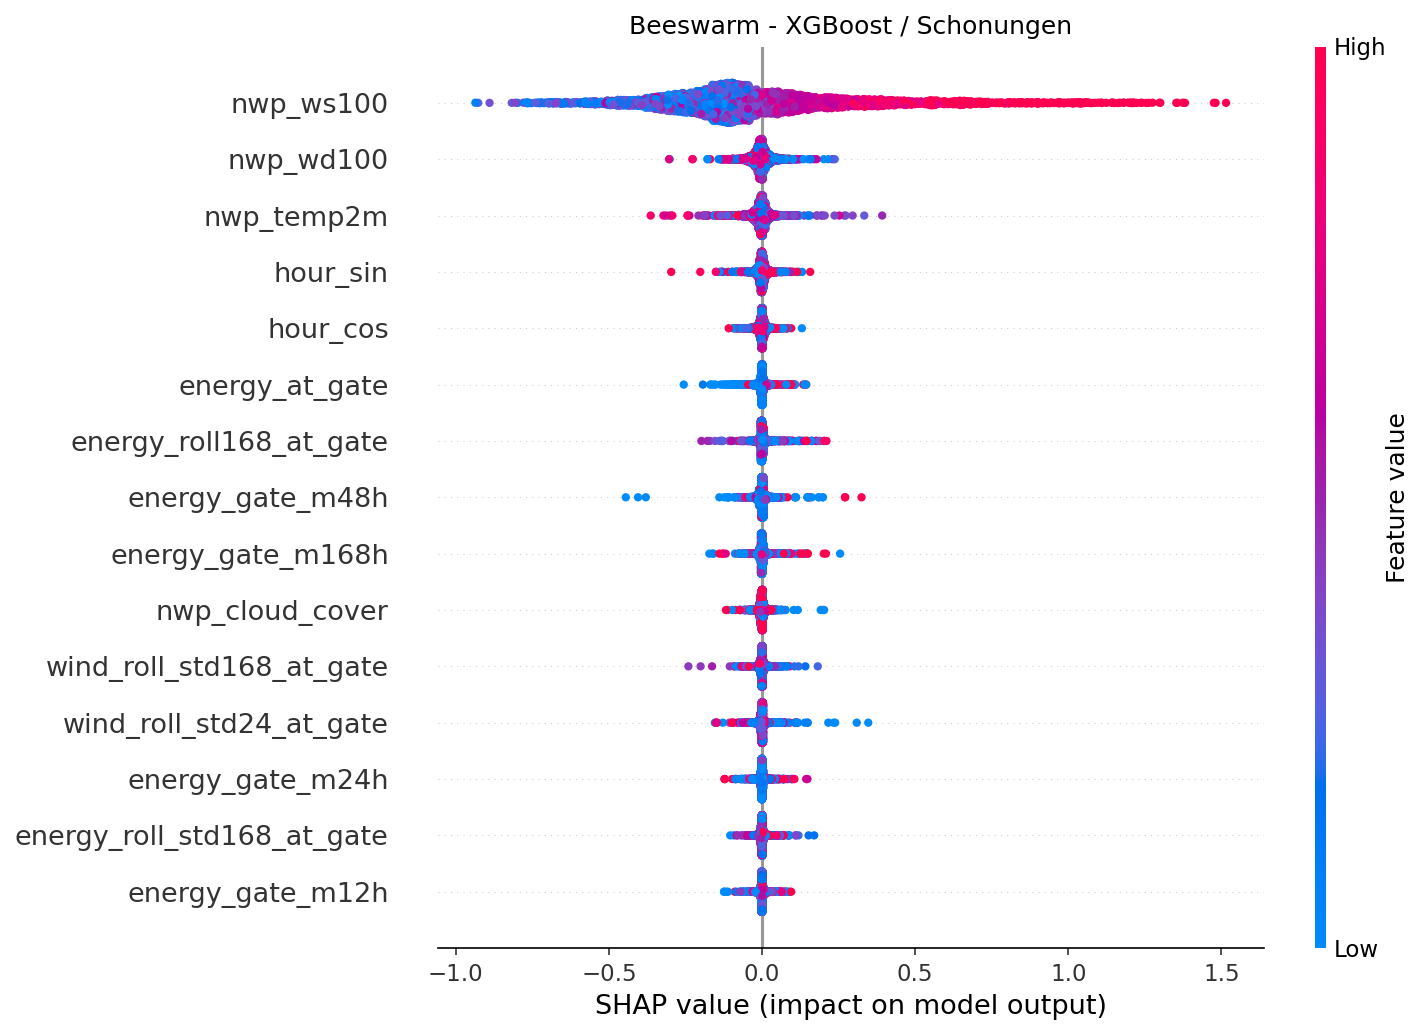

  beeswarm xgb OK


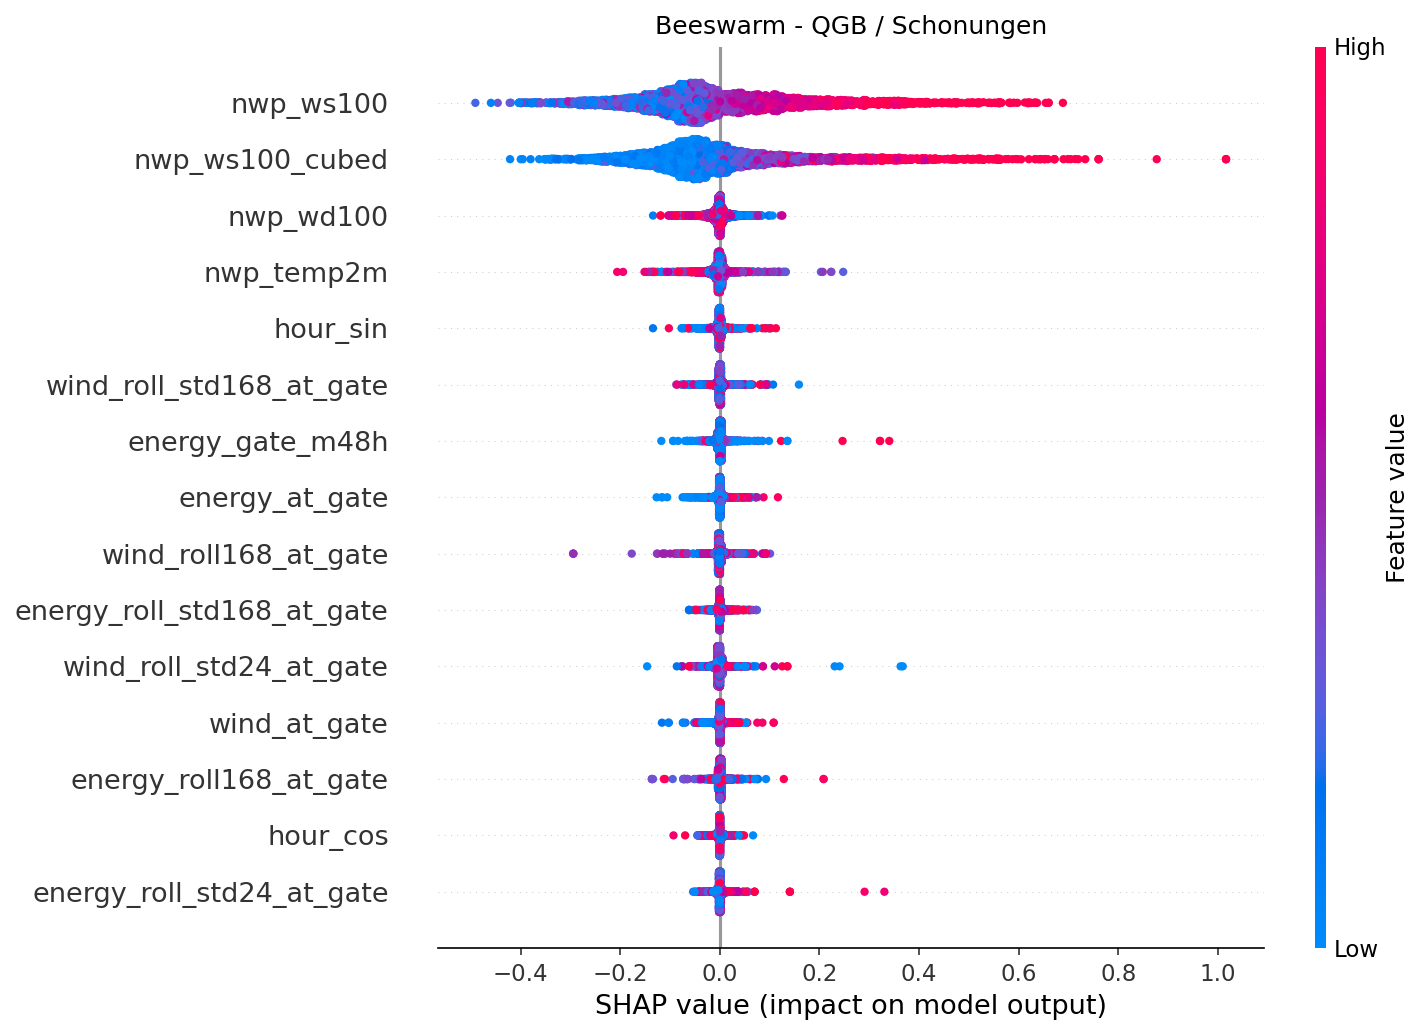

  beeswarm qgb OK


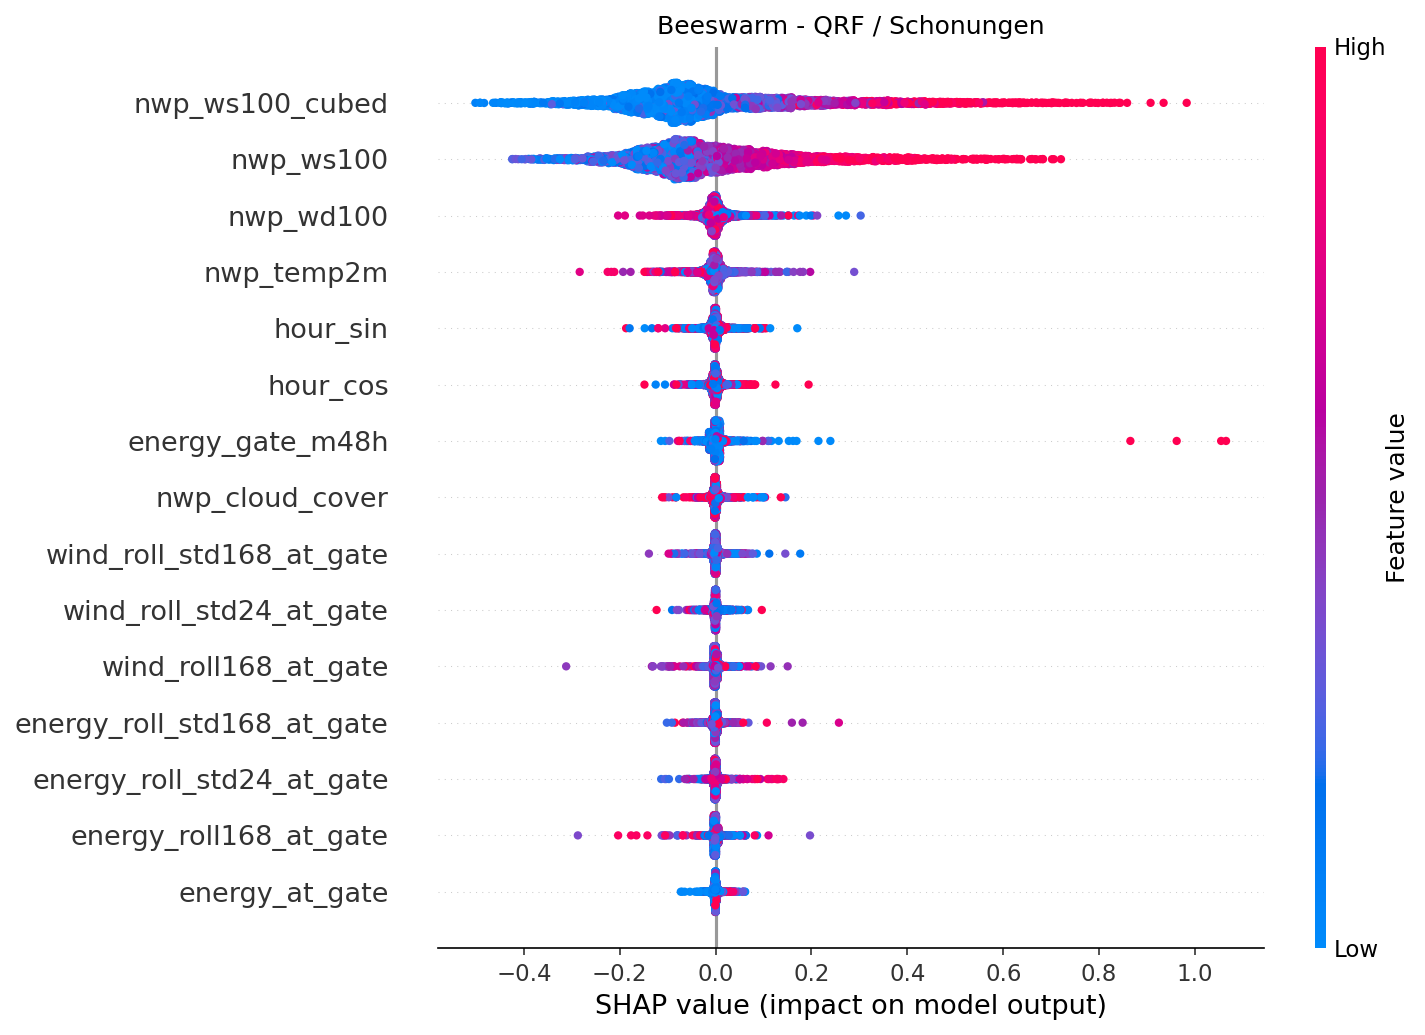

  beeswarm qrf OK


In [4]:
for mdl in ["xgb", "qgb", "qrf"]:
    d = shap_data[(PLOT_PLANT, mdl)]
    try:
        shap.summary_plot(d["shap_values"], np.asarray(d["X"]), feature_names=FEATURES,
                          max_display=15, show=False)
        fig = plt.gcf(); fig.set_size_inches(10, 7)
        plt.title(f"Beeswarm - {MODELS[mdl]} / {PLOT_PLANT}")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"shap_beeswarm_{mdl}_{PLOT_PLANT.lower()}.png", dpi=150)
        plt.show(); plt.close()
        print(f"  beeswarm {mdl} OK")
    except Exception as e:
        print(f"  beeswarm {mdl} FAILED: {e}")

## 4. Dependence Plot: nwp_ws100 (Windgeschwindigkeit) vs SHAP

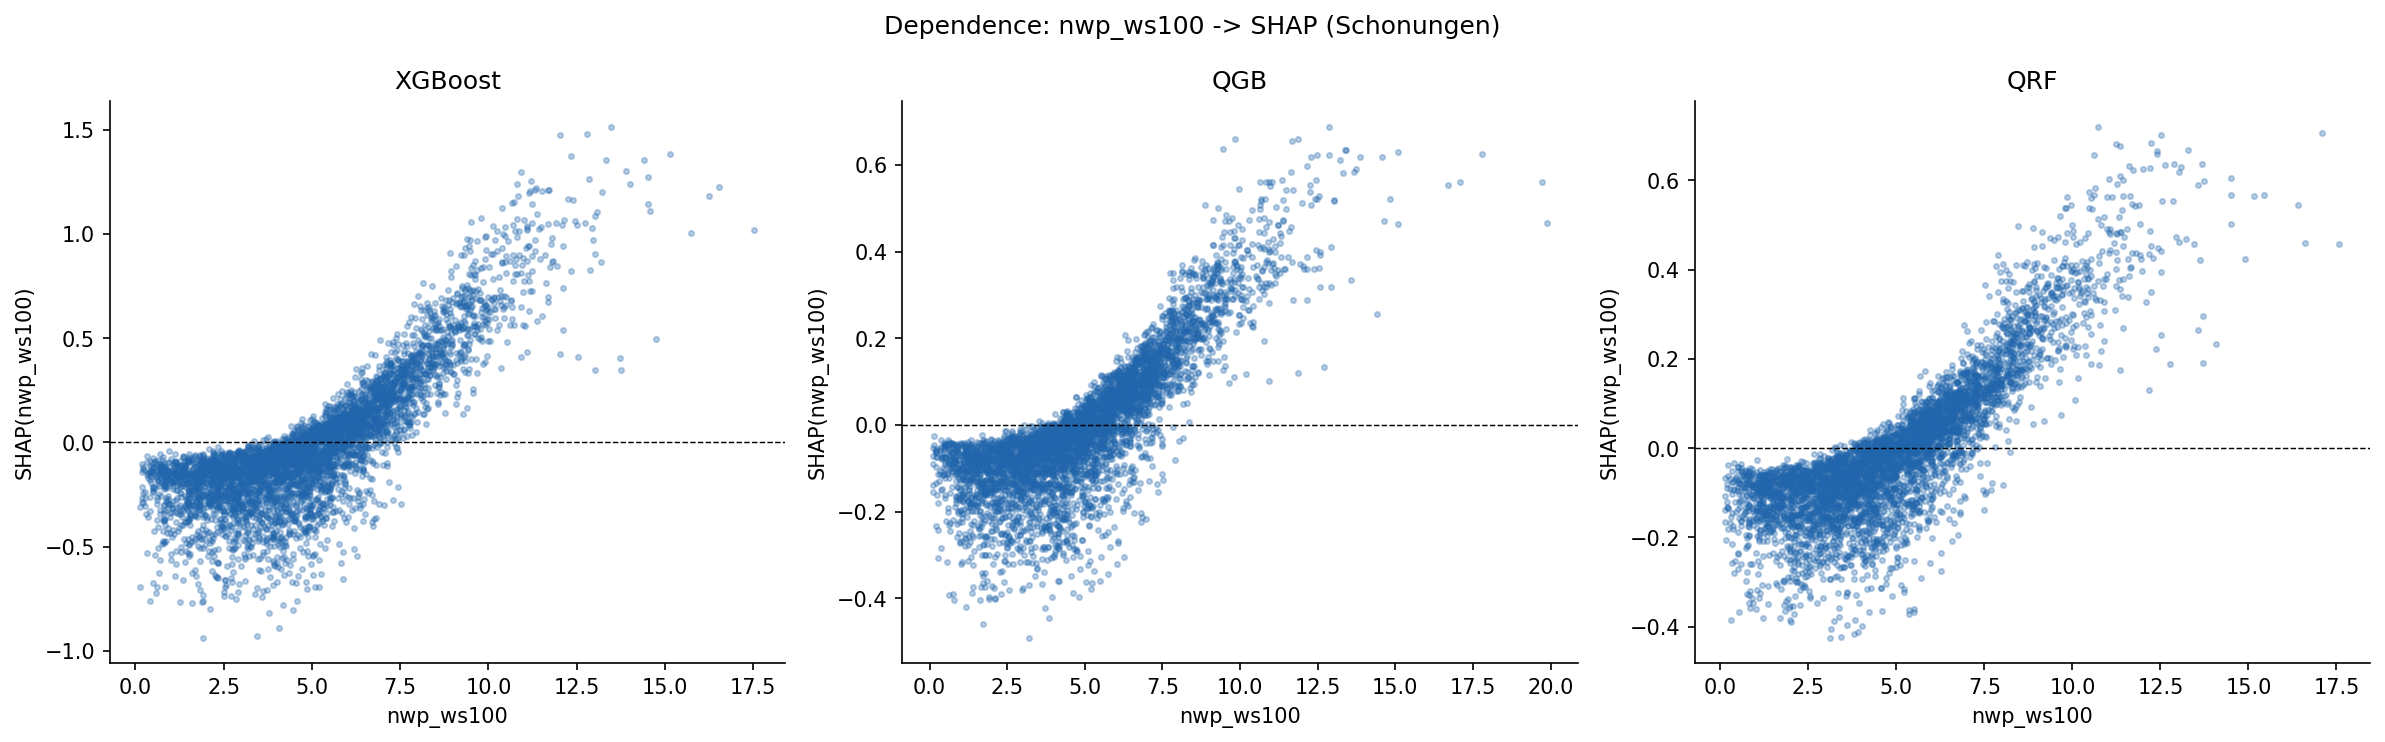

In [5]:
TOPF = "nwp_ws100" if "nwp_ws100" in FEATURES else FEATURES[int(np.argmax(np.abs(shap_data[(PLOT_PLANT,"qgb")]["shap_values"]).mean(0)))]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, mdl in zip(axes, ["xgb", "qgb", "qrf"]):
    d = shap_data[(PLOT_PLANT, mdl)]
    X = np.asarray(d["X"]); j = FEATURES.index(TOPF)
    ax.scatter(X[:, j], d["shap_values"][:, j], s=6, alpha=0.3, color="#2166ac")
    ax.axhline(0, color="k", lw=0.7, ls="--")
    ax.set_xlabel(TOPF); ax.set_ylabel(f"SHAP({TOPF})"); ax.set_title(MODELS[mdl])
plt.suptitle(f"Dependence: {TOPF} -> SHAP ({PLOT_PLANT})"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_dependence_{TOPF}_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 5. Waterfall Plot: einzelne Vorhersage (QGB, Schonungen)

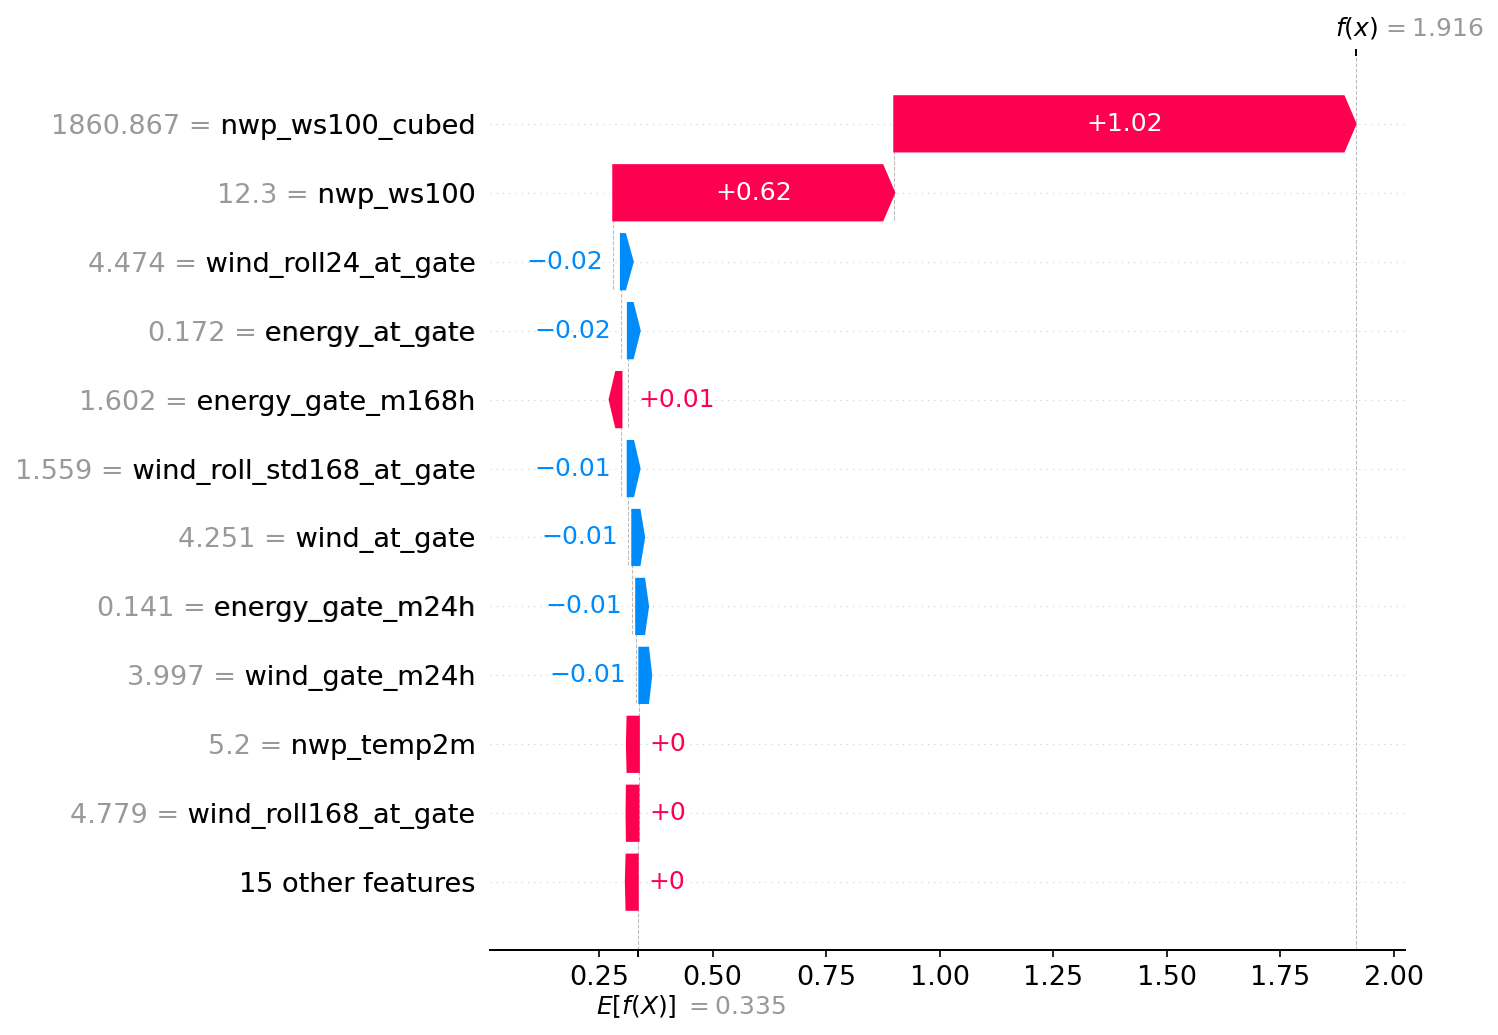

  waterfall OK (sample 4563, pred~1.916 MWh)


In [6]:
d = shap_data[(PLOT_PLANT, "qgb")]
sv = d["shap_values"]; X = np.asarray(d["X"]); base = float(d["base_value"])
i = int(np.argmax(np.abs(sv).sum(axis=1)))   # Sample mit staerkster Erklaerung
try:
    expl = shap.Explanation(values=sv[i], base_values=base, data=X[i], feature_names=FEATURES)
    shap.plots.waterfall(expl, max_display=12, show=False)
    fig = plt.gcf(); fig.set_size_inches(10, 7); plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_waterfall_qgb_{PLOT_PLANT.lower()}.png", dpi=150)
    plt.show(); plt.close()
    print(f"  waterfall OK (sample {i}, pred~{base + sv[i].sum():.3f} MWh)")
except Exception as e:
    print("  waterfall FAILED:", e)

## 6. Force Plot: dieselbe Vorhersage (lokal)

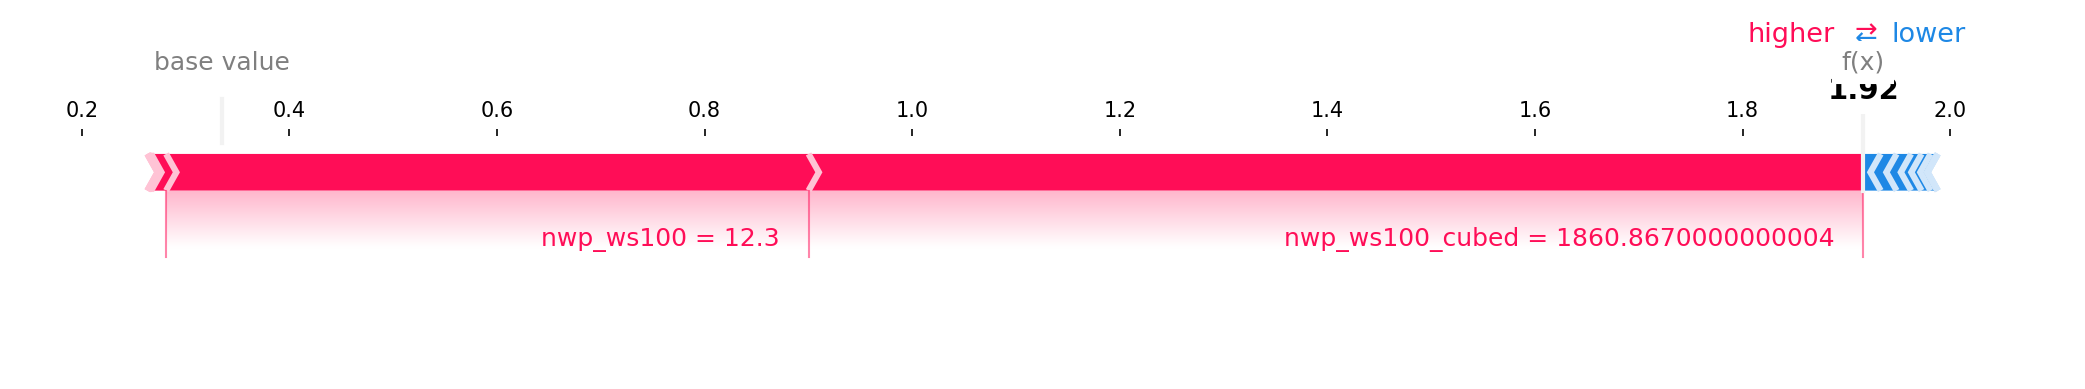

  force OK


In [7]:
try:
    shap.plots.force(base, sv[i], X[i], feature_names=FEATURES, matplotlib=True, show=False)
    fig = plt.gcf(); fig.set_size_inches(14, 3); plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_force_qgb_{PLOT_PLANT.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("  force OK")
except Exception as e:
    print("  force FAILED:", e)

## 7. Modellvergleich: MAE / RMSE / Pinball (Grouped Bar)

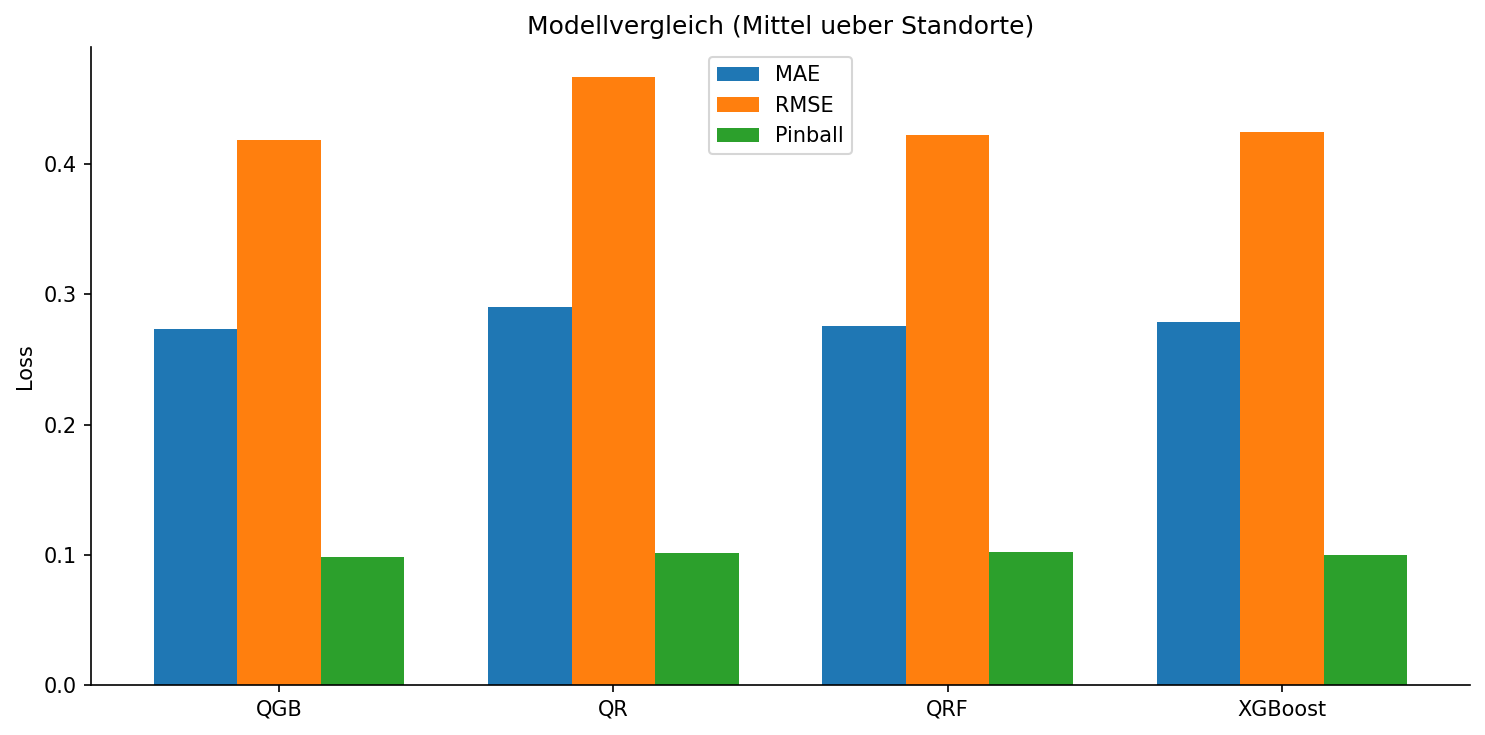

  model    MAE   RMSE  Pinball
    QGB 0.2731 0.4181   0.0984
     QR 0.2898 0.4666   0.1014
    QRF 0.2758 0.4223   0.1023
XGBoost 0.2790 0.4243   0.1003


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def pinball(y, yp, q): e = y - yp; return float(np.mean(np.maximum(q*e, (q-1)*e)))
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

comp = []
for p in PLANTS:
    fp = FORECAST_DIR / f"predictions_{p.lower()}.csv"
    if not fp.exists(): continue
    dfp = pd.read_csv(fp)
    y = dfp["y_true"].values
    for mdl in ["xgb", "qgb", "qrf", "qr"]:
        q50 = dfp[f"{mdl}_q50"].values
        pb = np.mean([pinball(y, dfp[f"{mdl}_q{int(q*100):02d}"].values, q) for q in QUANTILES])
        comp.append({"model": MODELS[mdl],
                     "MAE": mean_absolute_error(y, q50),
                     "RMSE": np.sqrt(mean_squared_error(y, q50)),
                     "Pinball": pb})
comp_df = pd.DataFrame(comp).groupby("model").mean().reset_index()
comp_df.to_csv(TABLES_DIR / "model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_df)); w = 0.25
for i, metric in enumerate(["MAE", "RMSE", "Pinball"]):
    ax.bar(x + (i-1)*w, comp_df[metric], w, label=metric)
ax.set_xticks(x); ax.set_xticklabels(comp_df["model"]); ax.set_ylabel("Loss")
ax.set_title("Modellvergleich (Mittel ueber Standorte)"); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "model_comparison_bars.png", dpi=150); plt.show()
print(comp_df.round(4).to_string(index=False))

## QR-Koeffizienten (β je Feature × Quantil, standardisiert)


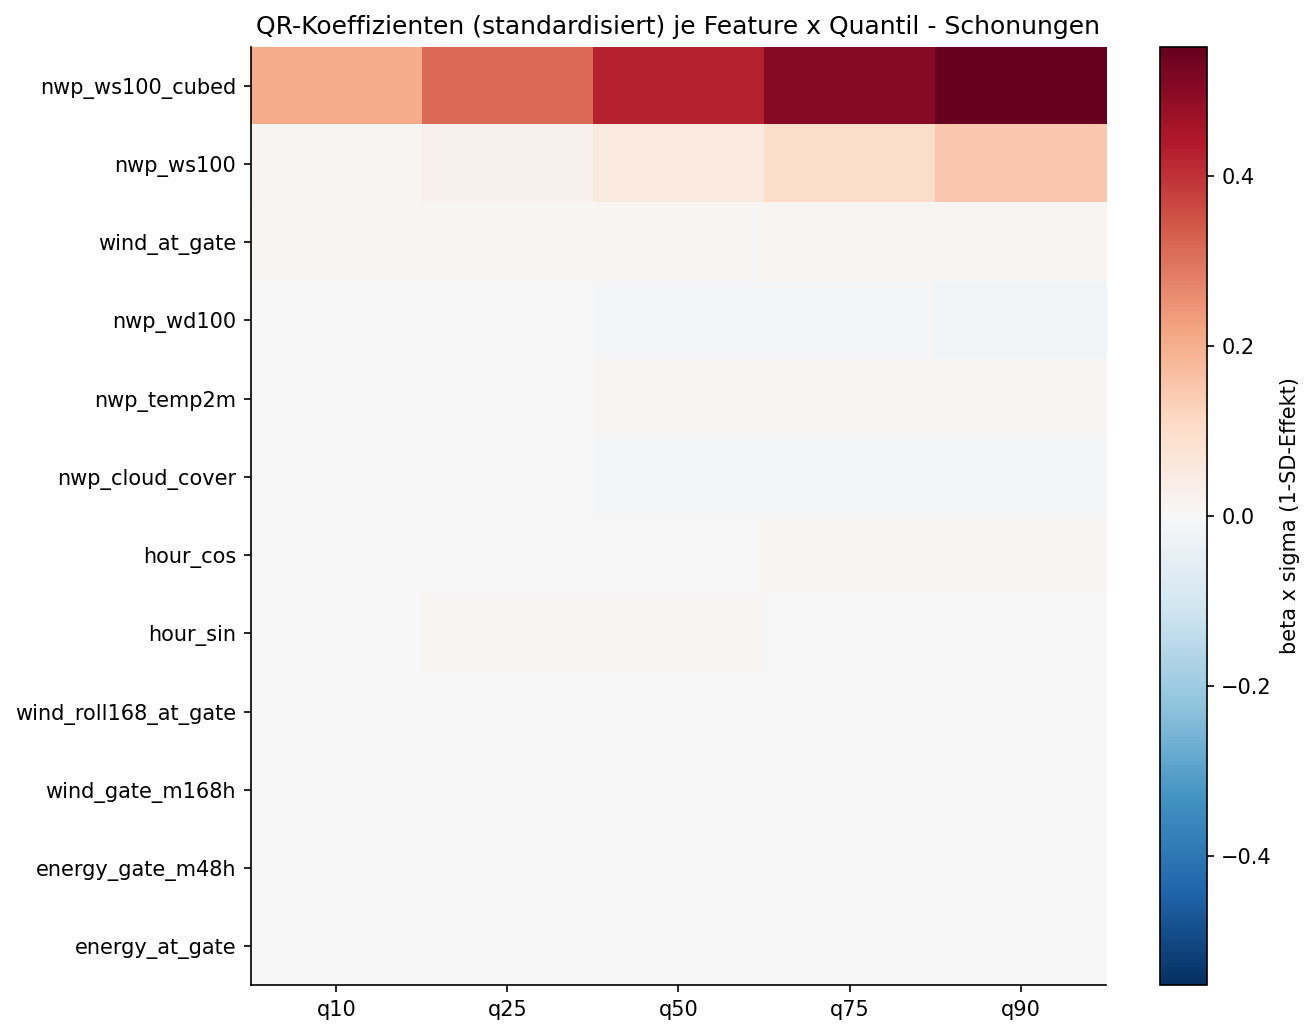

QR: v^3-Term dominiert, Effekt waechst q10->q90


In [9]:
fp = TABLES_DIR / f"qr_coefficients_{PLOT_PLANT.lower()}.csv"
if fp.exists():
    co = pd.read_csv(fp)
    Xstd = pd.Series(np.asarray(shap_data[(PLOT_PLANT, "qgb")]["X"]).std(axis=0), index=FEATURES)
    co["beta_z"] = co["beta_mean"] * co["feature"].map(Xstd)
    piv = co.pivot_table(index="feature", columns="quantile", values="beta_z")
    order = piv.abs().mean(axis=1).sort_values(ascending=False).head(12).index
    piv = piv.loc[order]
    vmax = float(np.nanmax(np.abs(piv.values))) or 1.0
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(piv.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f"q{int(q*100):02d}" for q in piv.columns])
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    ax.set_title(f"QR-Koeffizienten (standardisiert) je Feature x Quantil - {PLOT_PLANT}")
    plt.colorbar(im, ax=ax, label="beta x sigma (1-SD-Effekt)"); plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"qr_coefficients_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()
    print("QR: v^3-Term dominiert, Effekt waechst q10->q90")
else:
    print("qr_coefficients fehlt - erst NB03 laufen lassen")

## 8. Pinball Loss ueber Quantile (Line, mehrere Modelle)

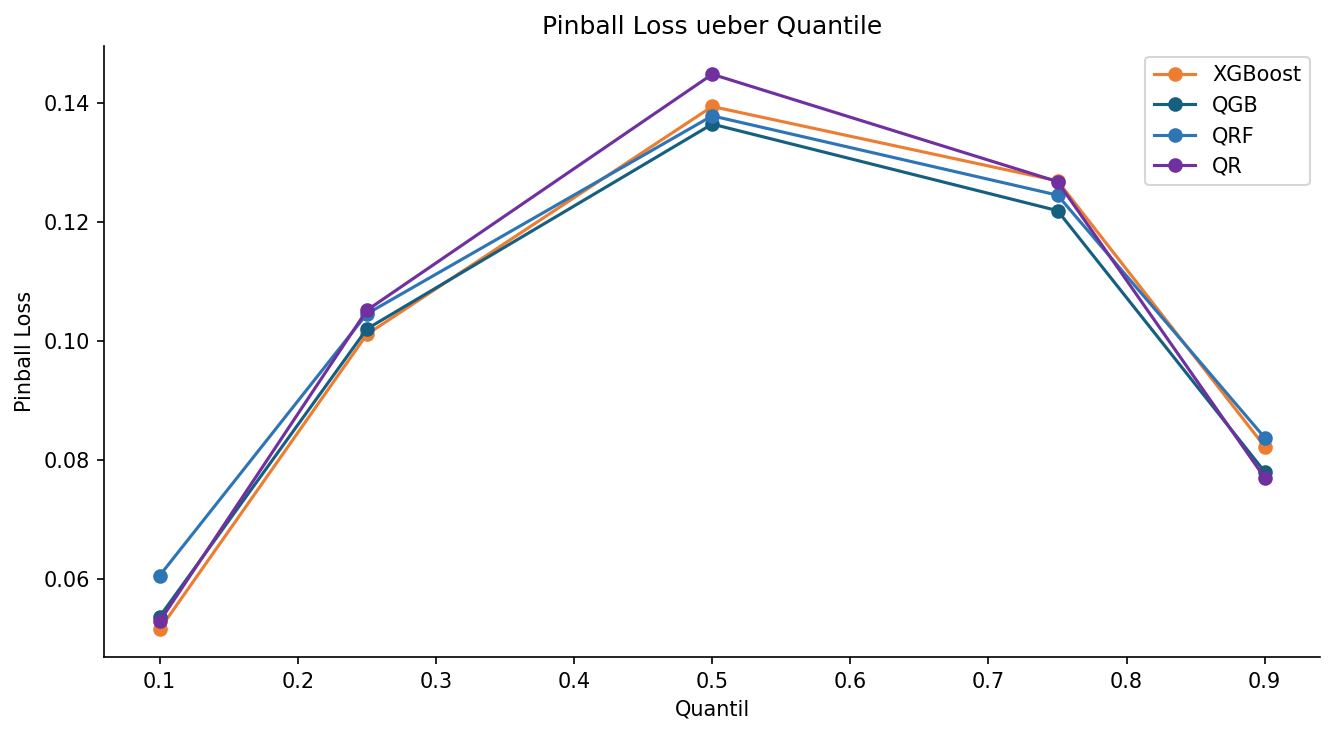

In [10]:
pb_path = TABLES_DIR / "pinball_evaluation.csv"
if pb_path.exists():
    pbdf = pd.read_csv(pb_path)
    agg = pbdf.groupby(["model", "quantile"])["pinball_loss"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(9, 5))
    for mdl, c in [("xgb", get_model_color("xgb")), ("qgb", get_model_color("qgb")), ("qrf", get_model_color("qrf")), ("qr", get_model_color("qr"))]:
        s = agg[agg["model"] == mdl].sort_values("quantile")
        if len(s): ax.plot(s["quantile"], s["pinball_loss"], marker="o", label=MODELS.get(mdl, mdl), color=c)
    ax.set_xlabel("Quantil"); ax.set_ylabel("Pinball Loss"); ax.set_title("Pinball Loss ueber Quantile")
    ax.legend(); plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pinball_over_quantiles.png", dpi=150); plt.show()
else:
    print("pinball_evaluation.csv fehlt")

## 9. SHAP-Heatmap: Stunde x Monat (Saisonalitaet, nwp_ws100 / QGB)

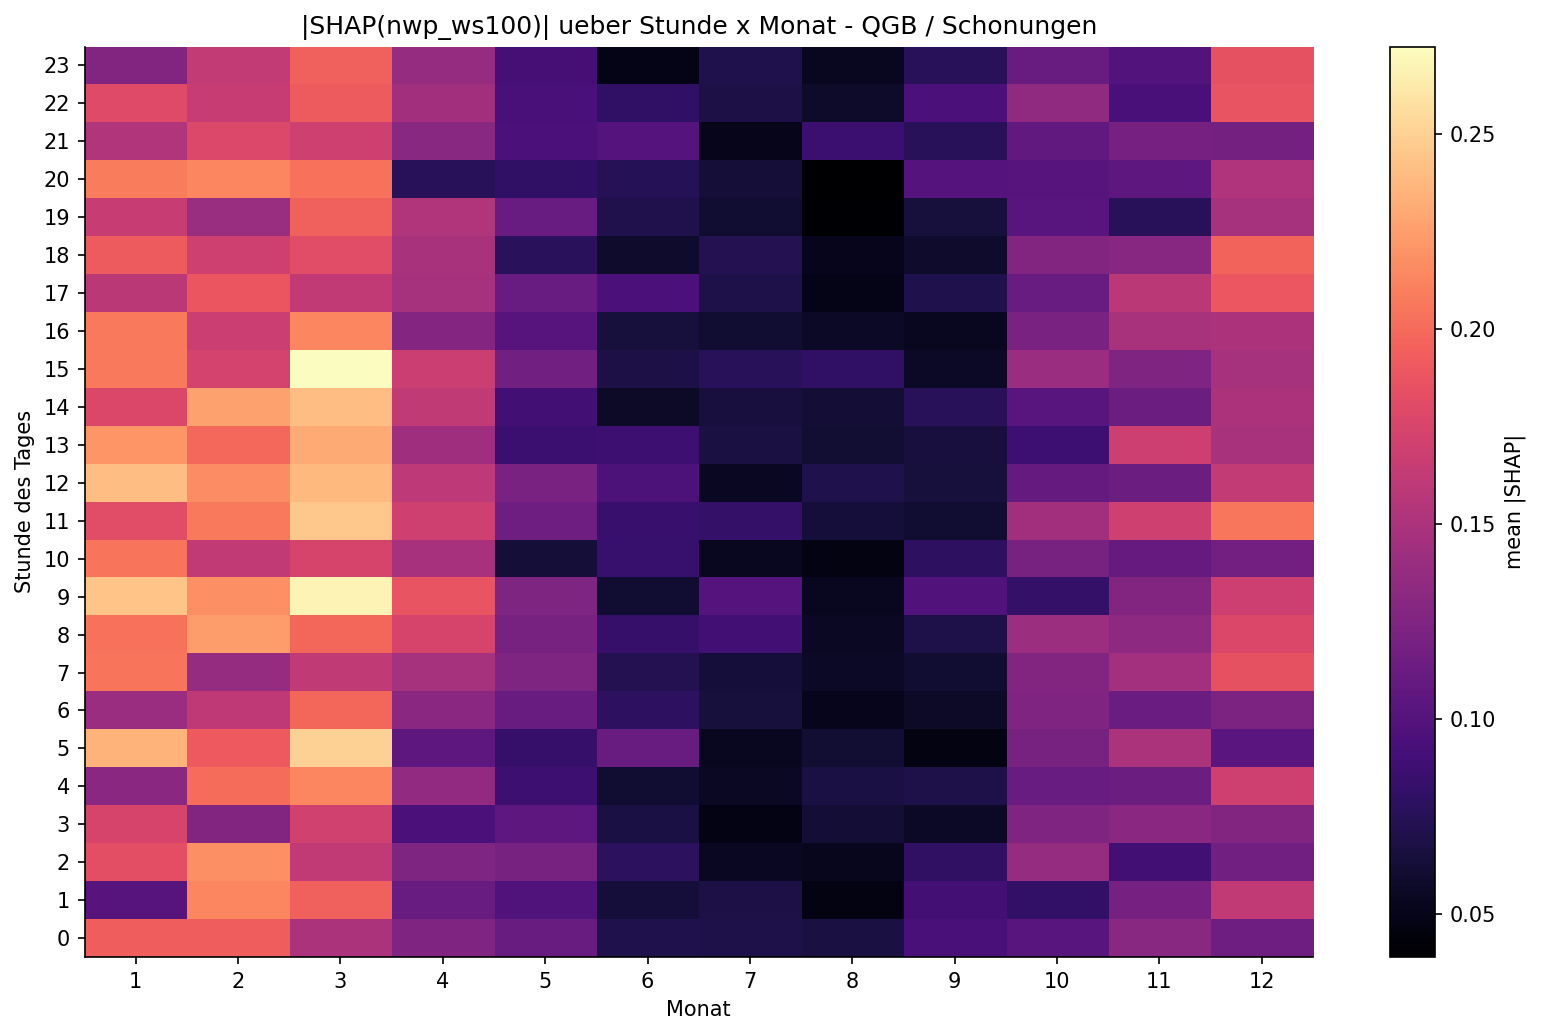

In [11]:
d = shap_data[(PLOT_PLANT, "qgb")]
ts = pd.to_datetime(d["timestamps"])
j = FEATURES.index(TOPF)
hm = pd.DataFrame({"hour": ts.hour, "month": ts.month, "abs_shap": np.abs(d["shap_values"][:, j])})
grid = hm.groupby(["hour", "month"])["abs_shap"].mean().unstack("month")
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(grid.values, aspect="auto", cmap="magma", origin="lower")
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels(grid.index)
ax.set_xlabel("Monat"); ax.set_ylabel("Stunde des Tages")
ax.set_title(f"|SHAP({TOPF})| ueber Stunde x Monat - {MODELS['qgb']} / {PLOT_PLANT}")
plt.colorbar(im, ax=ax, label="mean |SHAP|"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_heatmap_hour_month_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 10. Forecast vs Actual + Quantil-Baender (Beispielmonat)

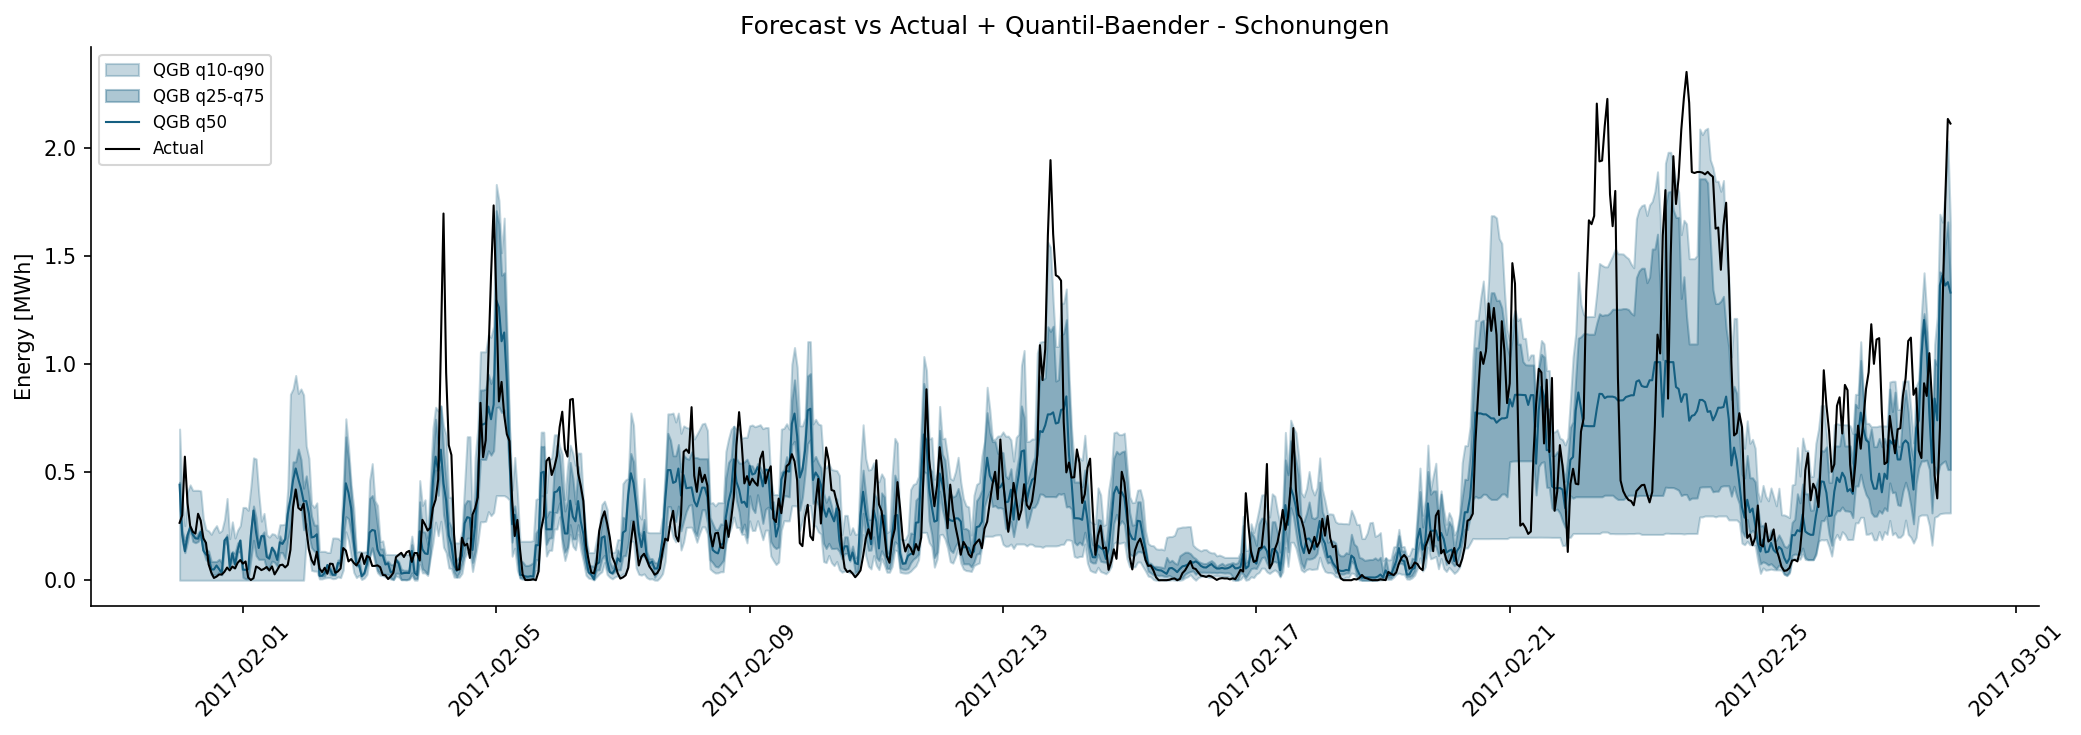

In [12]:
dfp = pd.read_csv(FORECAST_DIR / f"predictions_{PLOT_PLANT.lower()}.csv", parse_dates=["timestamp"])
m = dfp.sort_values("timestamp").iloc[:28*24]
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(m["timestamp"], m["qgb_q10"], m["qgb_q90"], alpha=0.25, color=get_model_color("qgb"), label="QGB q10-q90")
ax.fill_between(m["timestamp"], m["qgb_q25"], m["qgb_q75"], alpha=0.35, color=get_model_color("qgb"), label="QGB q25-q75")
ax.plot(m["timestamp"], m["qgb_q50"], color=get_model_color("qgb"), lw=1.0, label="QGB q50")
ax.plot(m["timestamp"], m["y_true"], color="black", lw=1.0, label="Actual")
ax.set_title(f"Forecast vs Actual + Quantil-Baender - {PLOT_PLANT}")
ax.set_ylabel("Energy [MWh]"); ax.legend(fontsize=8); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"forecast_bands_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()

## 12. Dependence nwp_ws100 mit Kubik-Referenz (P proportional v^3)

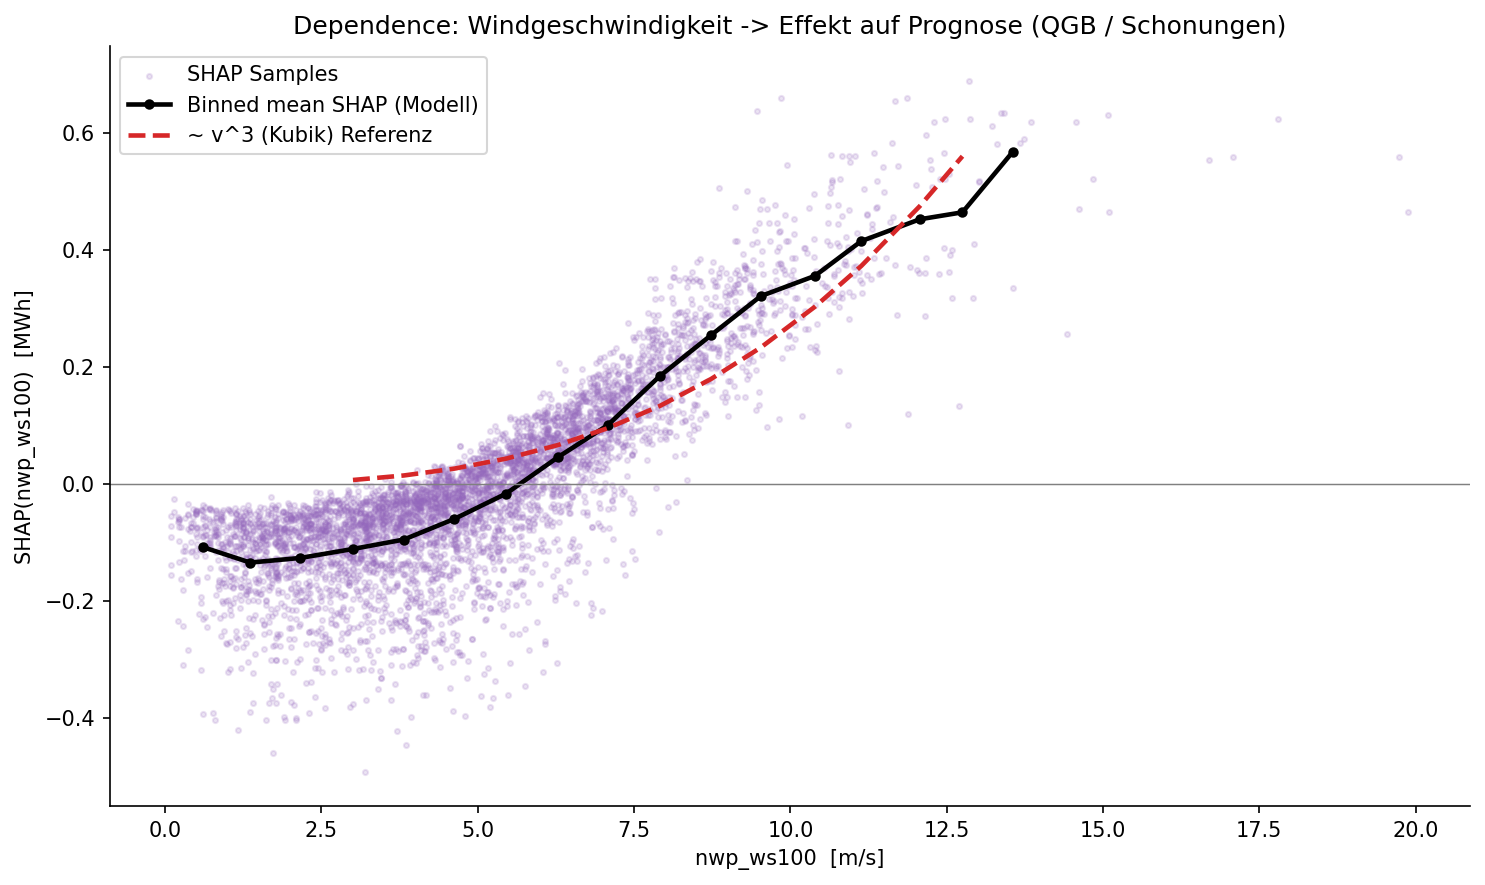

Anstieg im produktiven Bereich (3-13 m/s) folgt v^3, danach Saturation (Rated/Cut-out)


In [13]:
# Dependence nwp_ws100 mit Kubik-Referenz (P proportional v^3)
PP, MD = PLOT_PLANT, "qgb"
d = shap_data[(PP, MD)]
X = np.asarray(d["X"]); sv = d["shap_values"]; j = FEATURES.index("nwp_ws100")
ws, shp_ws = X[:, j], sv[:, j]

# Binned mean (gelernte Abhaengigkeit des Modells)
bins = np.linspace(np.nanmin(ws), np.nanmax(ws), 25)
bi = np.digitize(ws, bins)
bc, bm = [], []
for b in range(1, len(bins)):
    m = bi == b
    if m.sum() > 5:
        bc.append(ws[m].mean()); bm.append(shp_ws[m].mean())
bc, bm = np.array(bc), np.array(bm)

# v^3 Referenz: kleinste-Quadrate-Skalierung im Anstiegsbereich [3, 13] m/s
win = (bc >= 3) & (bc <= 13)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(ws, shp_ws, s=6, alpha=0.18, color="#9467bd", label="SHAP Samples")
ax.plot(bc, bm, color="black", lw=2.2, marker="o", ms=4, label="Binned mean SHAP (Modell)")
if win.sum() >= 2:
    k = np.sum(bm[win] * bc[win]**3) / np.sum(bc[win]**6)
    ax.plot(bc[win], k * bc[win]**3, color="#d62728", lw=2.2, ls="--", label="~ v^3 (Kubik) Referenz")
ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("nwp_ws100  [m/s]"); ax.set_ylabel("SHAP(nwp_ws100)  [MWh]")
ax.set_title(f"Dependence: Windgeschwindigkeit -> Effekt auf Prognose ({MODELS[MD]} / {PP})")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_dependence_cubic_{MD}_{PP.lower()}.png", dpi=150); plt.show()
print("Anstieg im produktiven Bereich (3-13 m/s) folgt v^3, danach Saturation (Rated/Cut-out)")

## 13. Beeswarm QGB - Richtung des Effekts

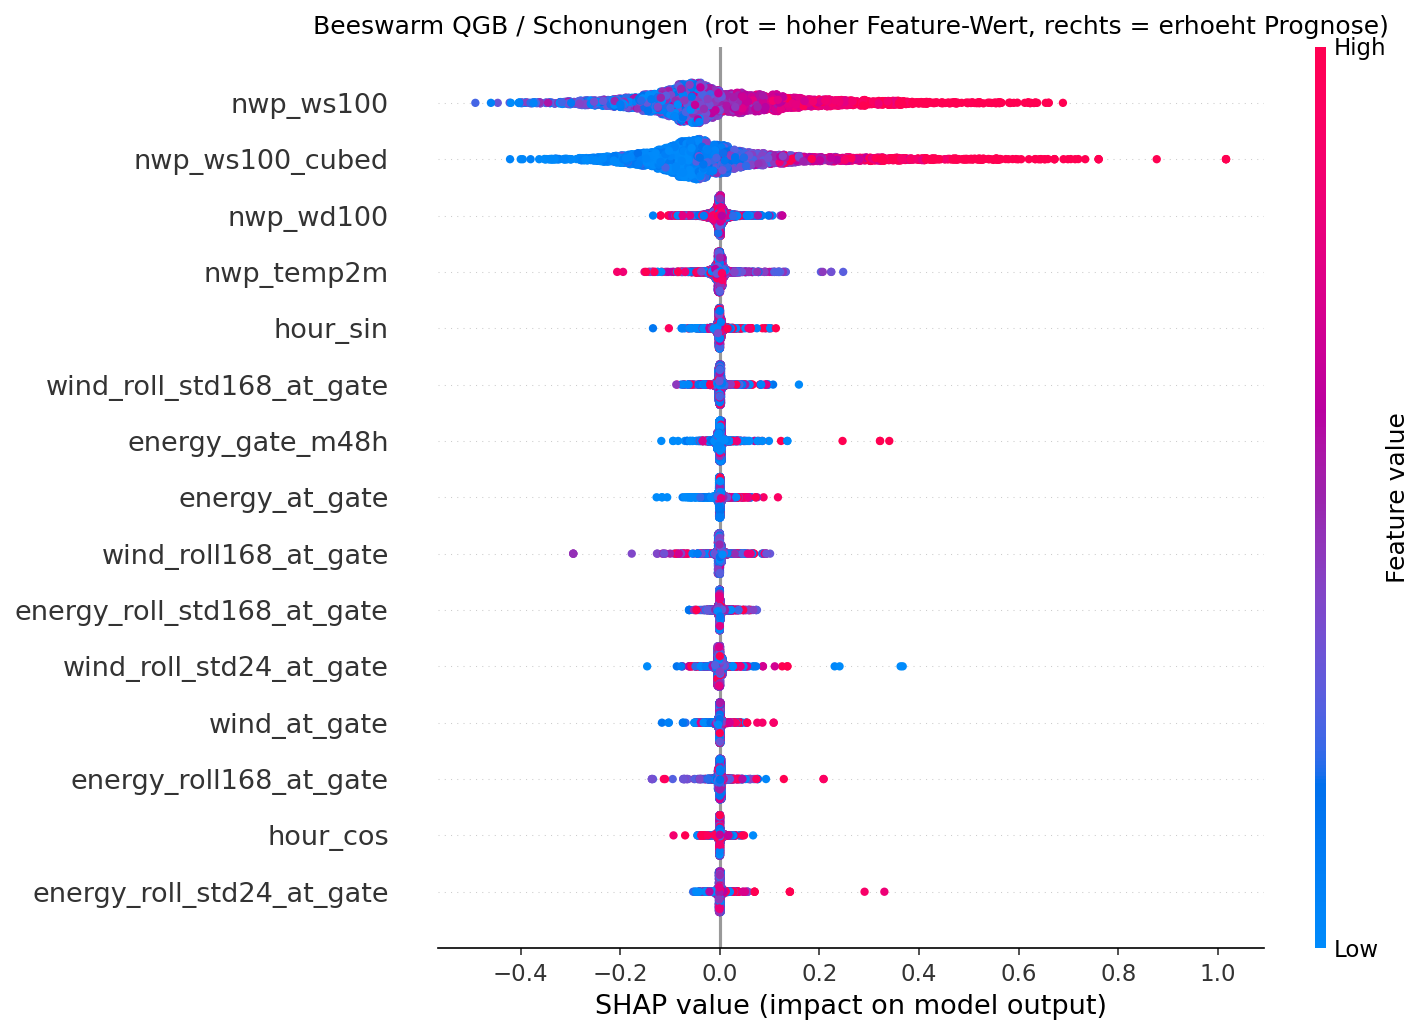

Lesart: nwp_ws100 - rote Punkte (hoher Wind) liegen rechts (positiver SHAP) -> hoher Wind erhoeht Prognose


In [14]:
# Beeswarm bestes Modell (QGB) - zeigt Wichtigkeit UND Richtung
d = shap_data[(PLOT_PLANT, "qgb")]
shap.summary_plot(d["shap_values"], np.asarray(d["X"]), feature_names=FEATURES,
                  max_display=15, show=False)
fig = plt.gcf(); fig.set_size_inches(10, 7)
plt.title(f"Beeswarm QGB / {PLOT_PLANT}  (rot = hoher Feature-Wert, rechts = erhoeht Prognose)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_beeswarm_featured_qgb_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()
print("Lesart: nwp_ws100 - rote Punkte (hoher Wind) liegen rechts (positiver SHAP) -> hoher Wind erhoeht Prognose")

## 14. Saisonale Feature-Importance (Winter vs Sommer)

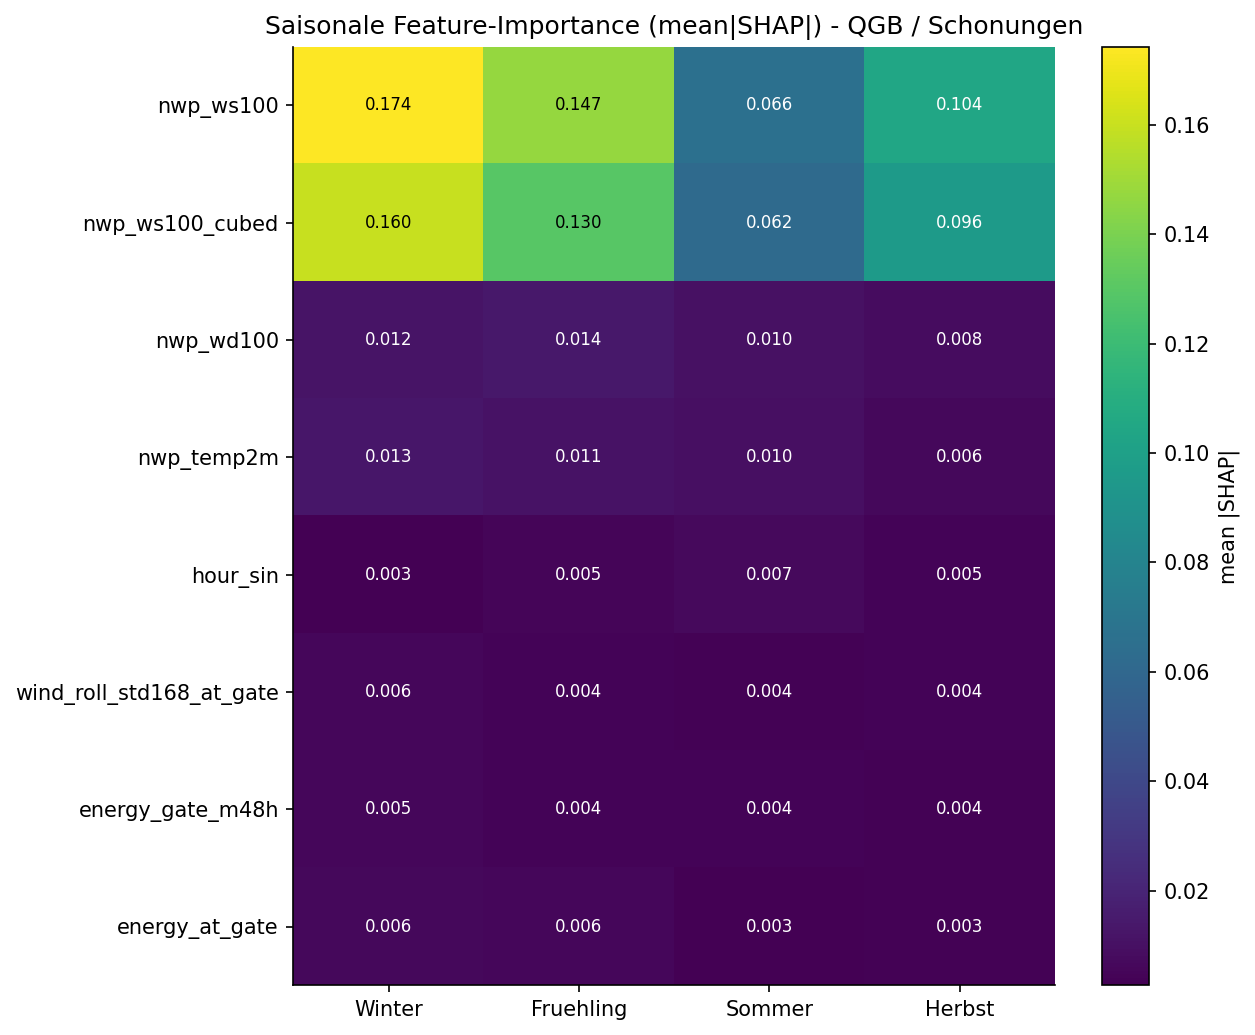

nwp_ws100 Importance: Winter=0.174  Sommer=0.066


In [15]:
# Saisonale Feature-Importance: Winter vs Sommer
d = shap_data[(PLOT_PLANT, "qgb")]
ts = pd.to_datetime(d["timestamps"]); A = np.abs(d["shap_values"])
mon = pd.Series(ts.month)
SEAS = {12:"Winter",1:"Winter",2:"Winter",3:"Fruehling",4:"Fruehling",5:"Fruehling",
        6:"Sommer",7:"Sommer",8:"Sommer",9:"Herbst",10:"Herbst",11:"Herbst"}
season = mon.map(SEAS)
order = ["Winter","Fruehling","Sommer","Herbst"]
topj = np.argsort(A.mean(0))[::-1][:8]
mat = np.zeros((len(topj), 4))
for si, s in enumerate(order):
    msk = (season == s).values
    if msk.sum() > 0:
        mat[:, si] = A[msk][:, topj].mean(0)
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(mat, aspect="auto", cmap="viridis")
ax.set_xticks(range(4)); ax.set_xticklabels(order)
ax.set_yticks(range(len(topj))); ax.set_yticklabels([FEATURES[j] for j in topj])
for yi in range(len(topj)):
    for xi in range(4):
        ax.text(xi, yi, f"{mat[yi,xi]:.3f}", ha="center", va="center",
                color="white" if mat[yi,xi] < mat.max()*0.6 else "black", fontsize=8)
ax.set_title(f"Saisonale Feature-Importance (mean|SHAP|) - {MODELS['qgb']} / {PLOT_PLANT}")
plt.colorbar(im, ax=ax, label="mean |SHAP|"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"shap_seasonal_importance_{PLOT_PLANT.lower()}.png", dpi=150); plt.show()
ws_row = list(topj).index(FEATURES.index("nwp_ws100")) if FEATURES.index("nwp_ws100") in topj else None
if ws_row is not None:
    print(f"nwp_ws100 Importance: Winter={mat[ws_row,0]:.3f}  Sommer={mat[ws_row,2]:.3f}")

## 11. Zusammenfassung

In [16]:
print("=== xAI Summary ===")
print(f"SHAP files: {len(shap_data)} (3 Modelle x 4 Standorte), je <= 5000 Samples mit X+base+timestamps")
print("Top-5 Features global:")
for f, v in imp_df.groupby("feature")["importance"].mean().nlargest(5).items():
    print(f"  {f:<28} {v:.4f}")
print()
print("Figures: shap_bar_importance, shap_beeswarm_*, shap_dependence_*, shap_waterfall_*,")
print("         shap_force_*, model_comparison_bars, pinball_over_quantiles,")
print("         shap_heatmap_hour_month_*, forecast_bands_*")

=== xAI Summary ===
SHAP files: 12 (3 Modelle x 4 Standorte), je <= 5000 Samples mit X+base+timestamps
Top-5 Features global:
  nwp_ws100                    0.2472
  nwp_ws100_cubed              0.1333
  nwp_wd100                    0.0290
  nwp_temp2m                   0.0226
  hour_sin                     0.0129

Figures: shap_bar_importance, shap_beeswarm_*, shap_dependence_*, shap_waterfall_*,
         shap_force_*, model_comparison_bars, pinball_over_quantiles,
         shap_heatmap_hour_month_*, forecast_bands_*


## 15. Fehleranalyse: Wann/Warum scheitern Gebote? (verbindet xAI mit Oekonomie)

In [17]:
# Fehleranalyse: Bidding-Detail (aus NB04) + Windgeschwindigkeit (NWP) laden
PP = PLOT_PLANT  # Schonungen
det = pd.read_csv(FORECAST_DIR / f"bidding_detail_{PP.lower()}.csv", parse_dates=["timestamp"])
nwp = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "nwp" / f"nwp_{PP.lower()}.csv", parse_dates=["timestamp"])[["timestamp", "nwp_ws100"]]
fa = det.merge(nwp, on="timestamp", how="left")
fa["hour"] = fa["timestamp"].dt.hour
fa["month"] = fa["timestamp"].dt.month
fa["imbalance"] = np.abs(fa["bid"] - fa["y_true"])
print(f"{len(fa)} Gebote | mean NV-Loss={fa['nv_loss'].mean():.3f} | mean |Imbalance|={fa['imbalance'].mean():.3f} MWh")

148608 Gebote | mean NV-Loss=2.040 | mean |Imbalance|=0.174 MWh


### 15a. NV-Loss vs. Wind & Prognose-Unsicherheit

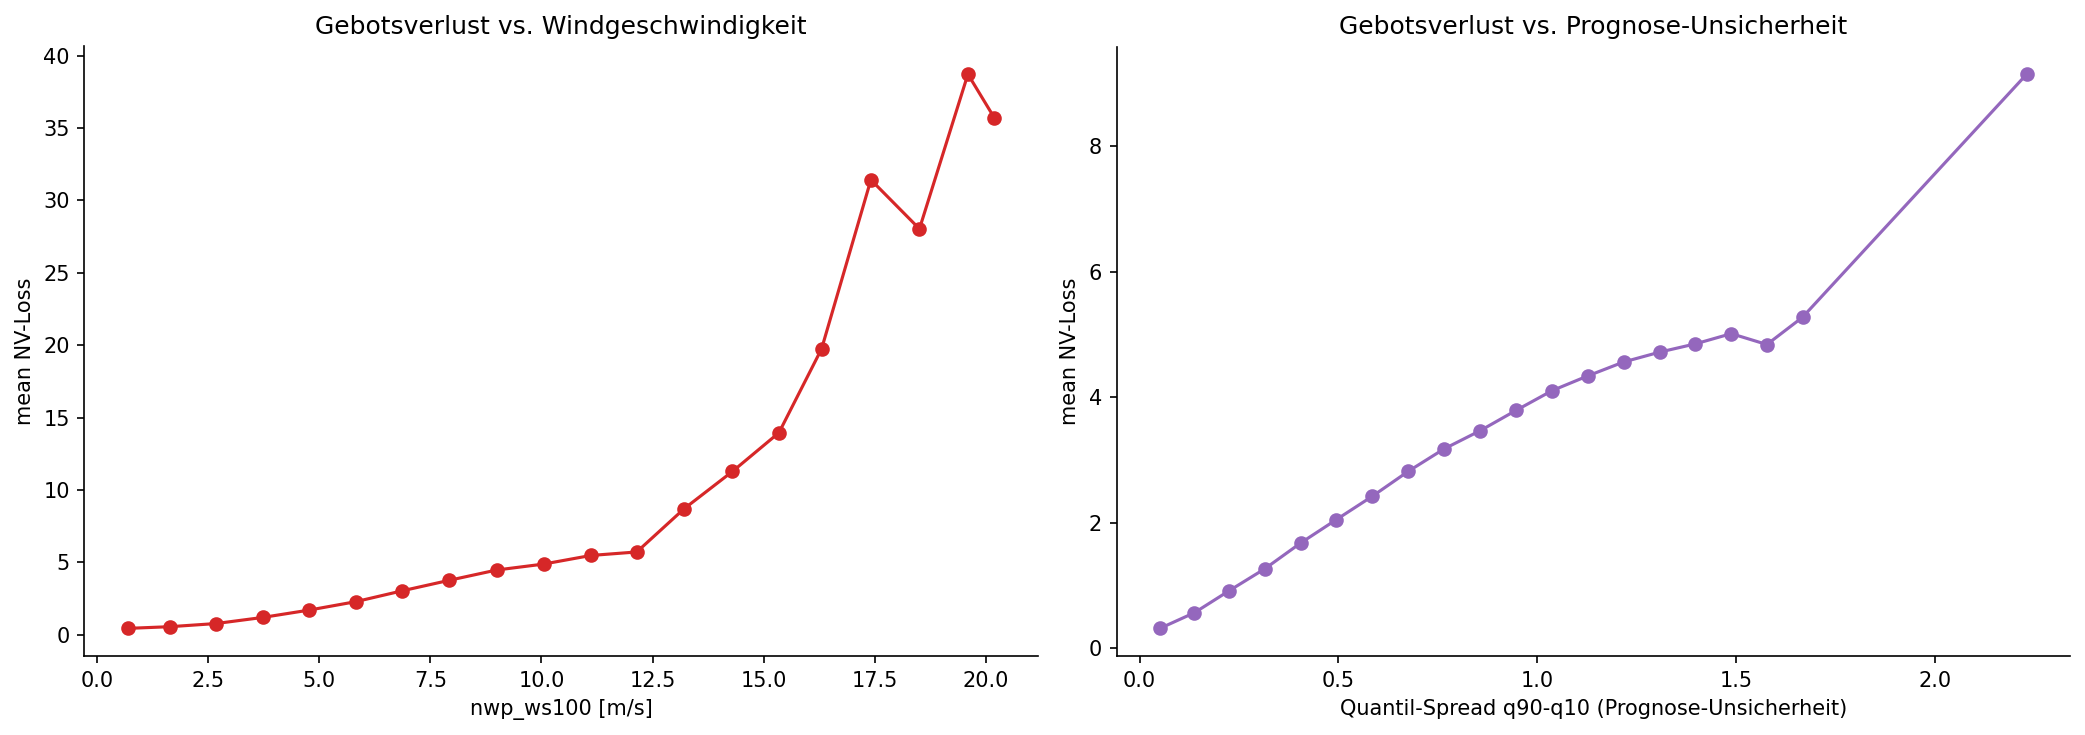

In [18]:
# Wann scheitern Gebote? NV-Loss vs. Windgeschwindigkeit und vs. Prognose-Unsicherheit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
b = np.linspace(fa["nwp_ws100"].min(), fa["nwp_ws100"].max(), 20)
fa["wb"] = np.digitize(fa["nwp_ws100"], b)
g = fa.groupby("wb").agg(ws=("nwp_ws100", "mean"), loss=("nv_loss", "mean"))
axes[0].plot(g["ws"], g["loss"], marker="o", color="#d62728")
axes[0].set_xlabel("nwp_ws100 [m/s]"); axes[0].set_ylabel("mean NV-Loss")
axes[0].set_title("Gebotsverlust vs. Windgeschwindigkeit")
b2 = np.linspace(fa["q_spread"].min(), fa["q_spread"].quantile(0.99), 20)
fa["sb"] = np.digitize(fa["q_spread"], b2)
g2 = fa.groupby("sb").agg(sp=("q_spread", "mean"), loss=("nv_loss", "mean"))
axes[1].plot(g2["sp"], g2["loss"], marker="o", color="#9467bd")
axes[1].set_xlabel("Quantil-Spread q90-q10 (Prognose-Unsicherheit)"); axes[1].set_ylabel("mean NV-Loss")
axes[1].set_title("Gebotsverlust vs. Prognose-Unsicherheit")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"bid_failure_conditions_{PP.lower()}.png", dpi=150); plt.show()

### 15b. Zeitliche Fehlerstruktur + Worst-Case

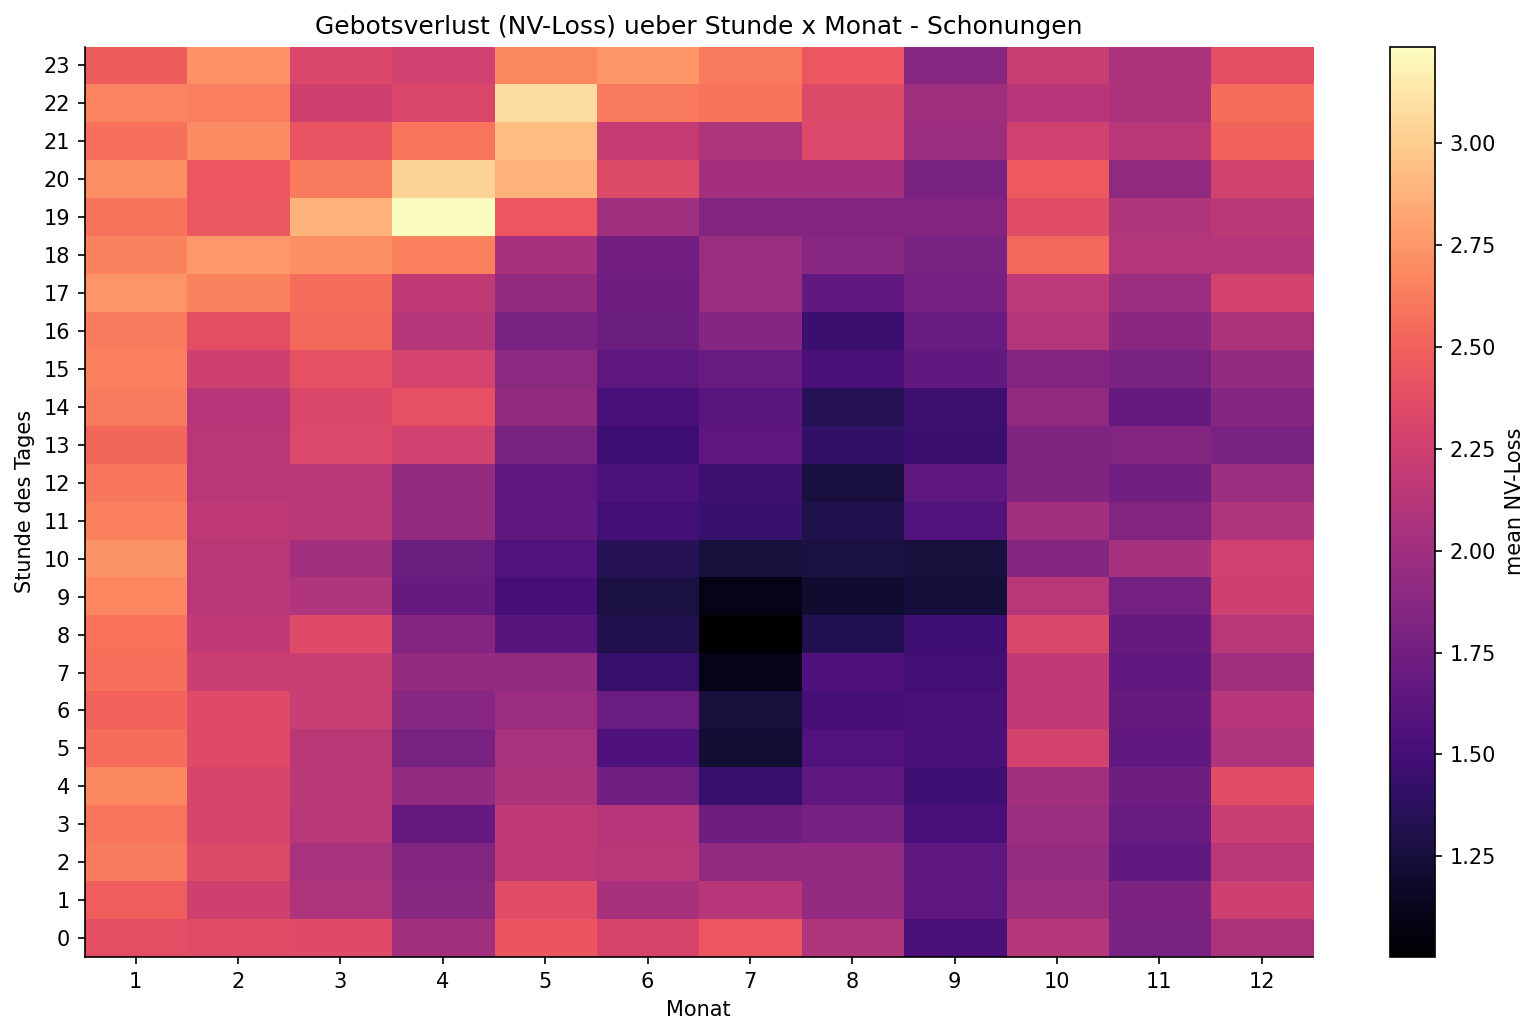

=== Schlimmste 5% Gebote (NV-Loss >= 6.84) ===
  mean Wind   = 8.7 m/s   (gesamt: 5.0)
  mean Spread = 1.103      (gesamt: 0.508)
  Haupt-Monate: {1: np.int64(1001), 3: np.int64(909), 2: np.int64(814)}
  -> Gebote scheitern v.a. bei hohem Wind und hoher Prognose-Unsicherheit


In [19]:
# Saisonale/zeitliche Fehlerstruktur + Worst-Case-Bedingungen
grid = fa.groupby(["hour", "month"])["nv_loss"].mean().unstack("month")
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(grid.values, aspect="auto", cmap="magma", origin="lower")
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels(grid.index)
ax.set_xlabel("Monat"); ax.set_ylabel("Stunde des Tages")
ax.set_title(f"Gebotsverlust (NV-Loss) ueber Stunde x Monat - {PP}")
plt.colorbar(im, ax=ax, label="mean NV-Loss"); plt.tight_layout()
plt.savefig(FIGURES_DIR / f"bid_failure_heatmap_{PP.lower()}.png", dpi=150); plt.show()

thr = fa["nv_loss"].quantile(0.95)
worst = fa[fa["nv_loss"] >= thr]
print(f"=== Schlimmste 5% Gebote (NV-Loss >= {thr:.2f}) ===")
print(f"  mean Wind   = {worst['nwp_ws100'].mean():.1f} m/s   (gesamt: {fa['nwp_ws100'].mean():.1f})")
print(f"  mean Spread = {worst['q_spread'].mean():.3f}      (gesamt: {fa['q_spread'].mean():.3f})")
print(f"  Haupt-Monate: {dict(worst['month'].value_counts().head(3))}")
hi_wind = worst['nwp_ws100'].mean() > fa['nwp_ws100'].mean()
hi_unc = worst['q_spread'].mean() > fa['q_spread'].mean()
print(f"  -> Gebote scheitern v.a. bei {'hohem' if hi_wind else 'niedrigem'} Wind"
      f" und {'hoher' if hi_unc else 'niedriger'} Prognose-Unsicherheit")

## 16. Cross-Site SHAP-Importance (probabilistisch)

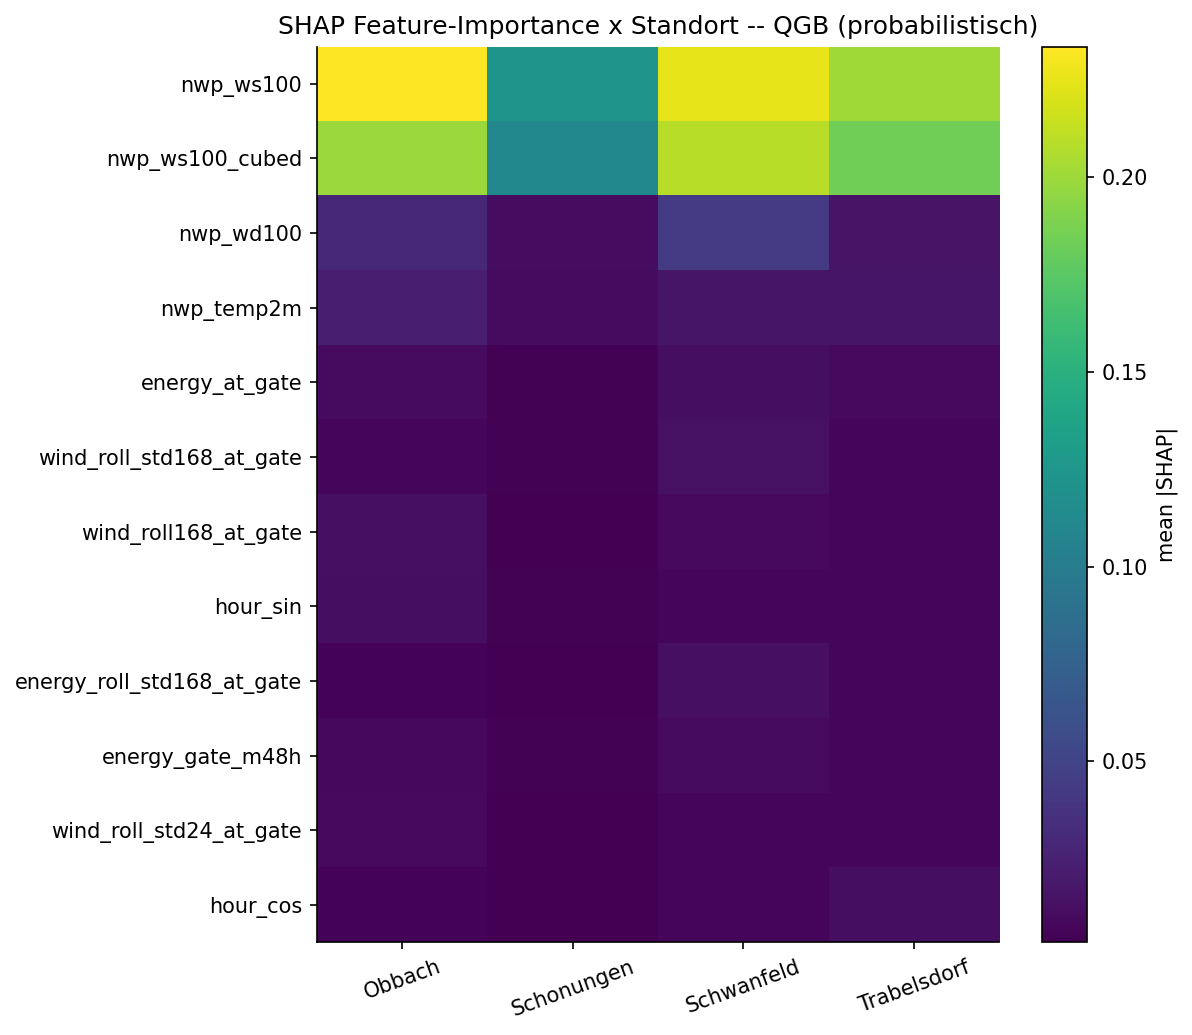

In [20]:
# Cross-Site SHAP Feature-Importance (QGB, probabilistisch) -- Heatmap Feature x Standort
MDL = "qgb"
rows = []
for s in PLANTS:
    d = shap_data[(s, MDL)]; imp = np.abs(d["shap_values"]).mean(0)
    for f, v in zip(FEATURES, imp):
        rows.append({"site": s, "feature": f, "imp": v})
idf = pd.DataFrame(rows).pivot_table(index="feature", columns="site", values="imp")
top = idf.mean(1).nlargest(12).index
idf = idf.loc[top]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(idf.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(idf.columns))); ax.set_xticklabels(idf.columns, rotation=20)
ax.set_yticks(range(len(idf.index))); ax.set_yticklabels(idf.index)
ax.set_title(f"SHAP Feature-Importance x Standort -- {MODELS[MDL]} (probabilistisch)")
plt.colorbar(im, ax=ax, label="mean |SHAP|"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "crosssite_shap_importance_qgb.png", dpi=150); plt.show()

## 17. Cross-Site Dependence nwp_ws100 (probabilistisch)

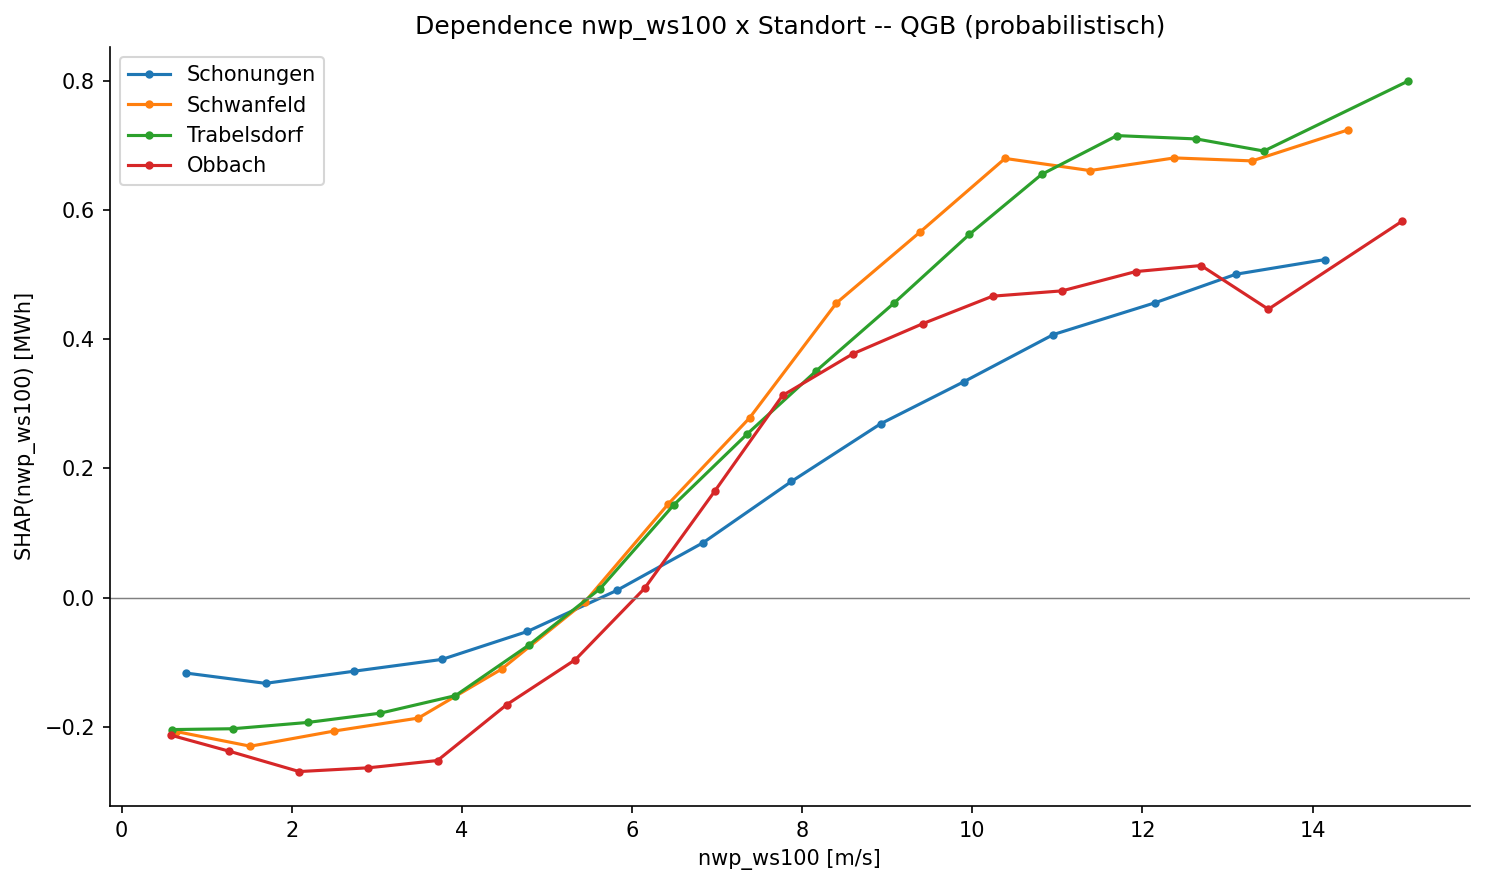

In [21]:
# Cross-Site Dependence nwp_ws100 (QGB) -- folgen alle Standorte der v^3-Kurve?
TOPF = "nwp_ws100"; j = FEATURES.index(TOPF)
SITECOL = {"Schonungen": "#1f77b4", "Schwanfeld": "#ff7f0e", "Trabelsdorf": "#2ca02c", "Obbach": "#d62728"}
fig, ax = plt.subplots(figsize=(10, 6))
for s in PLANTS:
    d = shap_data[(s, "qgb")]; X = np.asarray(d["X"]); ws = X[:, j]; sh = d["shap_values"][:, j]
    b = np.linspace(np.nanmin(ws), np.nanmax(ws), 20); bi = np.digitize(ws, b)
    bc, bm = [], []
    for k in range(1, len(b)):
        m = bi == k
        if m.sum() > 5: bc.append(ws[m].mean()); bm.append(sh[m].mean())
    ax.plot(bc, bm, marker="o", ms=3, label=s, color=SITECOL[s])
ax.axhline(0, color="gray", lw=0.7)
ax.set_xlabel("nwp_ws100 [m/s]"); ax.set_ylabel("SHAP(nwp_ws100) [MWh]")
ax.set_title("Dependence nwp_ws100 x Standort -- QGB (probabilistisch)")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "crosssite_dependence_nwp_ws100.png", dpi=150); plt.show()

## 18. Cross-Site saisonale Wind-Importance

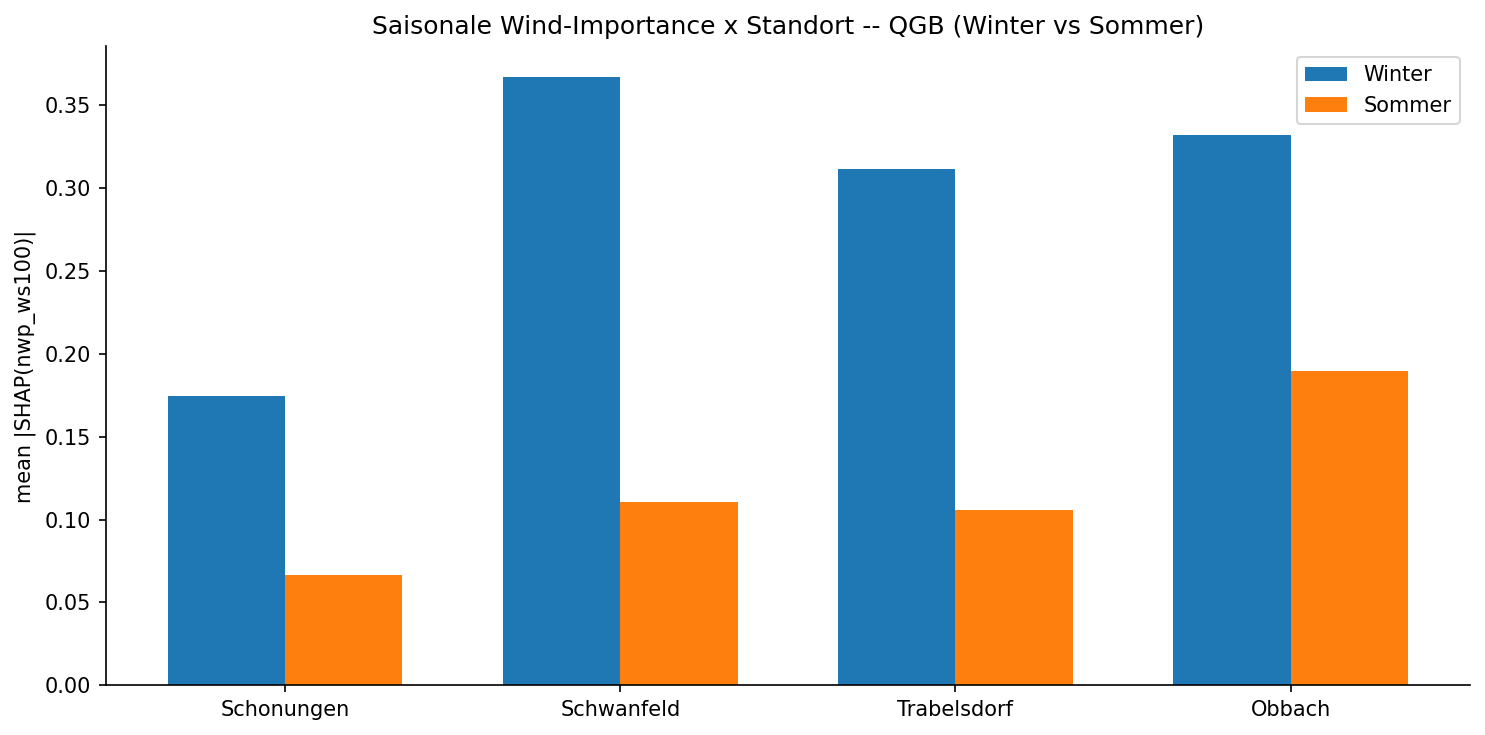

In [22]:
# Cross-Site Saisonale Wind-Importance (QGB) -- Winter vs Sommer je Standort
j = FEATURES.index("nwp_ws100")
SEAS = {12: "Winter", 1: "Winter", 2: "Winter", 6: "Sommer", 7: "Sommer", 8: "Sommer"}
rows = []
for s in PLANTS:
    d = shap_data[(s, "qgb")]; ts = pd.to_datetime(d["timestamps"]); a = np.abs(d["shap_values"][:, j])
    se = pd.Series(ts.month).map(SEAS)
    for season in ["Winter", "Sommer"]:
        m = (se == season).values
        if m.sum() > 0: rows.append({"site": s, "season": season, "imp": float(a[m].mean())})
sd = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5)); x = np.arange(len(PLANTS)); w = 0.35
for i, season in enumerate(["Winter", "Sommer"]):
    vals = [sd[(sd["site"] == s) & (sd["season"] == season)]["imp"].values[0] if len(sd[(sd["site"] == s) & (sd["season"] == season)]) else 0 for s in PLANTS]
    ax.bar(x + (i - 0.5) * w, vals, w, label=season, color="#1f77b4" if season == "Winter" else "#ff7f0e")
ax.set_xticks(x); ax.set_xticklabels(PLANTS); ax.set_ylabel("mean |SHAP(nwp_ws100)|")
ax.set_title("Saisonale Wind-Importance x Standort -- QGB (Winter vs Sommer)")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "crosssite_seasonal_wind.png", dpi=150); plt.show()

## 19. Cross-Site Bid-Failure vs Wind

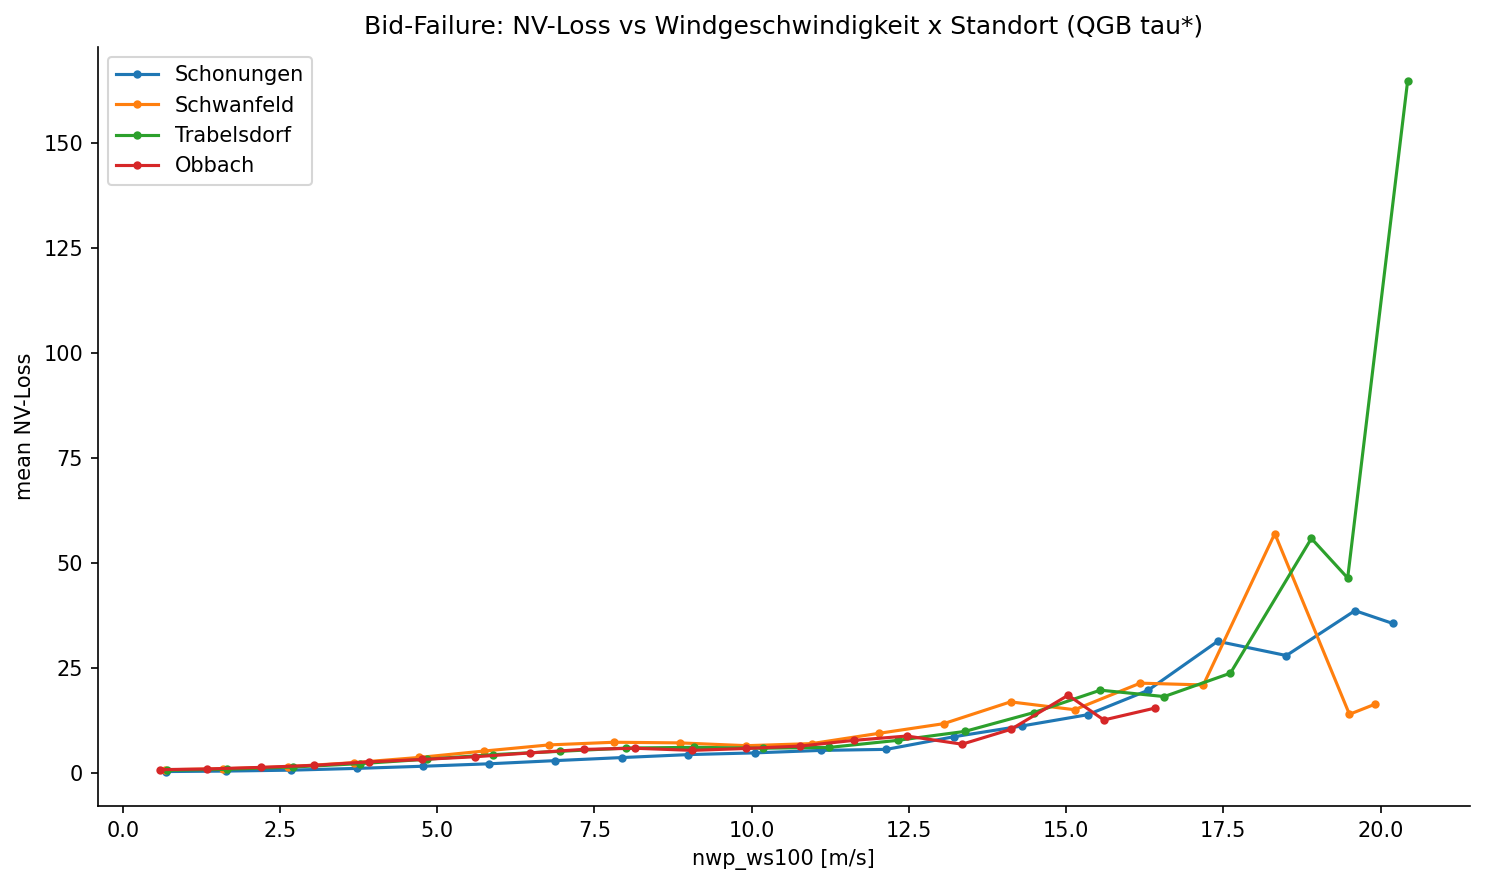

In [23]:
# Cross-Site Bid-Failure: NV-Loss vs Wind je Standort (QGB tau*-Gebot)
SITECOL = {"Schonungen": "#1f77b4", "Schwanfeld": "#ff7f0e", "Trabelsdorf": "#2ca02c", "Obbach": "#d62728"}
fig, ax = plt.subplots(figsize=(10, 6))
for s in PLANTS:
    det = pd.read_csv(FORECAST_DIR / f"bidding_detail_{s.lower()}.csv", parse_dates=["timestamp"])
    nwp = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "nwp" / f"nwp_{s.lower()}.csv", parse_dates=["timestamp"])[["timestamp", "nwp_ws100"]]
    fa = det.merge(nwp, on="timestamp", how="left")
    b = np.linspace(fa["nwp_ws100"].min(), fa["nwp_ws100"].max(), 20); fa["wb"] = np.digitize(fa["nwp_ws100"], b)
    g = fa.groupby("wb").agg(ws=("nwp_ws100", "mean"), loss=("nv_loss", "mean"))
    ax.plot(g["ws"], g["loss"], marker="o", ms=3, label=s, color=SITECOL[s])
ax.set_xlabel("nwp_ws100 [m/s]"); ax.set_ylabel("mean NV-Loss")
ax.set_title("Bid-Failure: NV-Loss vs Windgeschwindigkeit x Standort (QGB tau*)")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / "crosssite_bidfailure_wind.png", dpi=150); plt.show()